In [2]:
!pip -q install pandas numpy scikit-learn

In [3]:
import os
import json
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

In [ ]:
READY_PATH = "/content/wikiart_second_prompt_READY.csv"

df_ready = pd.read_csv(READY_PATH)

print(df_ready.shape)
display(df_ready.head())

(52951, 6)


,image,true_artist,pred_artist,style_macro,genre,img_url
0,102839-frank-w-benson-river-scene-1921.jpg,Frank W. Benson,John Henry Twachtman,Impressionism,landscape,https://uploads4.wikiart.org/00191/images/fran...
1,248823-badende-nach-tizian-1.jpg,Manuela Sambo,Julie Favaloro,Expressionism,portrait,https://uploads5.wikiart.org/00138/images/manu...
2,161158-rock-painting-motif.jpg,Walter Battiss,Jean Dubuffet,Naïve / Outsider,other,https://uploads4.wikiart.org/images/walter-bat...
3,39240-s-l1600.jpg,Alexander Clarot,Moritz Michael Daffinger,Romanticism,portrait,https://uploads3.wikiart.org/00332/images/alex...
4,24258-francis-godolphin-2nd-earl-of-godolphin-...,Jean-Baptiste van Loo,Balthasar Denner,Baroque,portrait,https://uploads8.wikiart.org/00308/images/jean...


In [ ]:
df_truth = df_ready.rename(columns={
    "style_macro": "true_macro_style",
    "genre": "true_genre",
    "pred_artist": "first_prompt_artist"
}).copy()


df_truth = df_truth[
    ["image", "img_url", "true_artist", "first_prompt_artist", "true_macro_style", "true_genre"]
].drop_duplicates(subset=["image"])

print("Shape df_truth:", df_truth.shape)
display(df_truth.head())

Shape df_truth: (52946, 6)


,image,img_url,true_artist,first_prompt_artist,true_macro_style,true_genre
0,102839-frank-w-benson-river-scene-1921.jpg,https://uploads4.wikiart.org/00191/images/fran...,Frank W. Benson,John Henry Twachtman,Impressionism,landscape
1,248823-badende-nach-tizian-1.jpg,https://uploads5.wikiart.org/00138/images/manu...,Manuela Sambo,Julie Favaloro,Expressionism,portrait
2,161158-rock-painting-motif.jpg,https://uploads4.wikiart.org/images/walter-bat...,Walter Battiss,Jean Dubuffet,Naïve / Outsider,other
3,39240-s-l1600.jpg,https://uploads3.wikiart.org/00332/images/alex...,Alexander Clarot,Moritz Michael Daffinger,Romanticism,portrait
4,24258-francis-godolphin-2nd-earl-of-godolphin-...,https://uploads8.wikiart.org/00308/images/jean...,Jean-Baptiste van Loo,Balthasar Denner,Baroque,portrait


In [ ]:
df_gemini = pd.read_csv("/content/results_gemini.csv")

print(df_gemini.shape)
display(df_gemini.head())

(7539, 27)


,dataset,model,timestamp_utc,image,img_url,true_artist,pred_artist_firstprompt,true_style_macro,true_genre,artist_guess_1,...,wol_linear_vs_painterly,wol_plane_vs_recession,wol_closed_vs_open_form,wol_multiplicity_vs_unity,wol_absolute_vs_relative_clarity,short_description,pred_is_structured,pred_raw,ok,error
0,wikiart,models/gemini-2.5-flash,2026-03-02T08:04:02.252503,102839-frank-w-benson-river-scene-1921.jpg,https://uploads4.wikiart.org/00191/images/fran...,Frank W. Benson,John Henry Twachtman,Impressionism,landscape,J. Alden Weir,...,5,5,4,5,4,A vibrant landscape depicts a sunlit meadow wi...,True,NaN,True,NaN
1,wikiart,models/gemini-2.5-flash,2026-03-02T08:04:14.678885,248823-badende-nach-tizian-1.jpg,https://uploads5.wikiart.org/00138/images/manu...,Manuela Sambo,Julie Favaloro,Expressionism,portrait,Arpana Caur,...,1,2,1,2,1,A vertical painting depicts a stylized nude fe...,True,NaN,True,NaN
2,wikiart,models/gemini-2.5-flash,2026-03-02T08:04:32.111702,161158-rock-painting-motif.jpg,https://uploads4.wikiart.org/images/walter-bat...,Walter Battiss,Jean Dubuffet,Naïve / Outsider,other,Hans Hartung,...,2,2,3,2,2,"An abstract artwork features a dark, textured,...",True,NaN,True,NaN
3,wikiart,models/gemini-2.5-flash,2026-03-02T08:04:52.102276,39240-s-l1600.jpg,https://uploads3.wikiart.org/00332/images/alex...,Alexander Clarot,Moritz Michael Daffinger,Romanticism,portrait,Jean-Baptiste Isabey,...,4,3,2,5,2,An oval miniature portrait depicting a fair-sk...,True,NaN,True,NaN
4,wikiart,models/gemini-2.5-flash,2026-03-02T08:05:02.791710,24258-francis-godolphin-2nd-earl-of-godolphin-...,https://uploads8.wikiart.org/00308/images/jean...,Jean-Baptiste van Loo,Balthasar Denner,Baroque,portrait,Sir Godfrey Kneller,...,2,3,1,5,1,A half-length portrait depicts a man with a la...,True,NaN,True,NaN


In [ ]:
df_gemini_eval = df_gemini[[
    "image",
    "artist_guess_1",
    "artist_guess_2",
    "artist_guess_3",
    "macro_style_pred",
    "genre_pred",
    "school_pred",
    "historical_period_pred",
    "wol_linear_vs_painterly",
    "wol_plane_vs_recession",
    "wol_closed_vs_open_form",
    "wol_multiplicity_vs_unity",
    "wol_absolute_vs_relative_clarity",
    "ok",
    "error"
]].copy()

# rinomina con gemini
df_gemini_eval = df_gemini_eval.rename(columns={
    "artist_guess_1": "gemini_artist_guess_1",
    "artist_guess_2": "gemini_artist_guess_2",
    "artist_guess_3": "gemini_artist_guess_3",
    "macro_style_pred": "gemini_macro_style_pred",
    "genre_pred": "gemini_genre_pred",
    "school_pred": "gemini_school_pred",
    "historical_period_pred": "gemini_historical_period_pred",
    "wol_linear_vs_painterly": "gemini_wol_linear_vs_painterly",
    "wol_plane_vs_recession": "gemini_wol_plane_vs_recession",
    "wol_closed_vs_open_form": "gemini_wol_closed_vs_open_form",
    "wol_multiplicity_vs_unity": "gemini_wol_multiplicity_vs_unity",
    "wol_absolute_vs_relative_clarity": "gemini_wol_absolute_vs_relative_clarity",
    "ok": "gemini_ok",
    "error": "gemini_error"
})

print("Shape df_gemini_eval:", df_gemini_eval.shape)
display(df_gemini_eval.head())

Shape df_gemini_eval: (7539, 15)


,image,gemini_artist_guess_1,gemini_artist_guess_2,gemini_artist_guess_3,gemini_macro_style_pred,gemini_genre_pred,gemini_school_pred,gemini_historical_period_pred,gemini_wol_linear_vs_painterly,gemini_wol_plane_vs_recession,gemini_wol_closed_vs_open_form,gemini_wol_multiplicity_vs_unity,gemini_wol_absolute_vs_relative_clarity,gemini_ok,gemini_error
0,102839-frank-w-benson-river-scene-1921.jpg,J. Alden Weir,John Twachtman,Childe Hassam,Impressionism,landscape,american,1851-1900,5,5,4,5,4,True,NaN
1,248823-badende-nach-tizian-1.jpg,Arpana Caur,Kiki Smith,Frida Kahlo,Symbolism / Intimism,mythological,other,1851-1900,1,2,1,2,1,True,NaN
2,161158-rock-painting-motif.jpg,Hans Hartung,Pierre Soulages,Wols,Abstract (large family),other,french,1851-1900,2,2,3,2,2,True,NaN
3,39240-s-l1600.jpg,Jean-Baptiste Isabey,Daniel Saint,Sir William Ross,Academic / Traditional,portrait,french,1801-1850,4,3,2,5,2,True,NaN
4,24258-francis-godolphin-2nd-earl-of-godolphin-...,Sir Godfrey Kneller,Jonathan Richardson the Elder,Joseph Highmore,Academic / Traditional,portrait,english,1701-1750,2,3,1,5,1,True,NaN


In [ ]:
df_gem = df_truth.merge(df_gemini_eval, on="image", how="inner")

print("Rows:", len(df_gem))
df_gem.head()

Rows: 7539


,image,img_url,true_artist,first_prompt_artist,true_macro_style,true_genre,gemini_artist_guess_1,gemini_artist_guess_2,gemini_artist_guess_3,gemini_macro_style_pred,gemini_genre_pred,gemini_school_pred,gemini_historical_period_pred,gemini_wol_linear_vs_painterly,gemini_wol_plane_vs_recession,gemini_wol_closed_vs_open_form,gemini_wol_multiplicity_vs_unity,gemini_wol_absolute_vs_relative_clarity,gemini_ok,gemini_error
0,102839-frank-w-benson-river-scene-1921.jpg,https://uploads4.wikiart.org/00191/images/fran...,Frank W. Benson,John Henry Twachtman,Impressionism,landscape,J. Alden Weir,John Twachtman,Childe Hassam,Impressionism,landscape,american,1851-1900,5,5,4,5,4,True,NaN
1,248823-badende-nach-tizian-1.jpg,https://uploads5.wikiart.org/00138/images/manu...,Manuela Sambo,Julie Favaloro,Expressionism,portrait,Arpana Caur,Kiki Smith,Frida Kahlo,Symbolism / Intimism,mythological,other,1851-1900,1,2,1,2,1,True,NaN
2,161158-rock-painting-motif.jpg,https://uploads4.wikiart.org/images/walter-bat...,Walter Battiss,Jean Dubuffet,Naïve / Outsider,other,Hans Hartung,Pierre Soulages,Wols,Abstract (large family),other,french,1851-1900,2,2,3,2,2,True,NaN
3,39240-s-l1600.jpg,https://uploads3.wikiart.org/00332/images/alex...,Alexander Clarot,Moritz Michael Daffinger,Romanticism,portrait,Jean-Baptiste Isabey,Daniel Saint,Sir William Ross,Academic / Traditional,portrait,french,1801-1850,4,3,2,5,2,True,NaN
4,24258-francis-godolphin-2nd-earl-of-godolphin-...,https://uploads8.wikiart.org/00308/images/jean...,Jean-Baptiste van Loo,Balthasar Denner,Baroque,portrait,Sir Godfrey Kneller,Jonathan Richardson the Elder,Joseph Highmore,Academic / Traditional,portrait,english,1701-1750,2,3,1,5,1,True,NaN


In [ ]:
import re
import unicodedata

def normalize_full(name):
    if pd.isna(name):
        return ""

    name = str(name).lower().strip()
    name = unicodedata.normalize("NFKD", name).encode("ascii","ignore").decode("utf-8")
    name = re.sub(r"[^\w\s]", "", name)

    return name

def extract_tokens(name):

    name = normalize_full(name)

    tokens = name.split()

    tokens = [t for t in tokens if len(t) > 1]

    stopwords = {"the","van","de","da","di"}
    tokens = [t for t in tokens if t not in stopwords]

    return set(tokens)

In [ ]:
def artist_top3_correct(row):

    true_tokens = extract_tokens(row["true_artist"])

    preds = [
        row["gemini_artist_guess_1"],
        row["gemini_artist_guess_2"],
        row["gemini_artist_guess_3"]
    ]

    for p in preds:

        pred_tokens = extract_tokens(p)

        if true_tokens == pred_tokens:
            return True

    return False

df_gem["artist_top3_correct"] = df_gem.apply(artist_top3_correct, axis=1)

In [ ]:
correct = df_gem["artist_top3_correct"].sum()
total = len(df_gem)

print("Gemini Artist Top-3:")
print(correct, "/", total)
print(f"{correct/total*100:.2f}%")

Gemini Artist Top-3:
792 / 7539
10.51%


In [ ]:
df_gem["style_correct"] = (
    df_gem["true_macro_style"].str.lower().str.strip()
    ==
    df_gem["gemini_macro_style_pred"].str.lower().str.strip()
)

style_acc = df_gem["style_correct"].mean()

print("Macro style accuracy:")
print(f"{style_acc*100:.2f}%")

Macro style accuracy:
49.66%


In [ ]:
df_gem["genre_correct"] = (
    df_gem["true_genre"].str.lower().str.strip()
    ==
    df_gem["gemini_genre_pred"].str.lower().str.strip()
)

genre_acc = df_gem["genre_correct"].mean()

print("Genre accuracy:")
print(f"{genre_acc*100:.2f}%")

Genre accuracy:
80.82%


In [ ]:
results_gemini = pd.DataFrame([{
    "model": "Gemini",
    "artist_top3_accuracy": df_gem["artist_top3_correct"].mean(),
    "macro_style_accuracy": df_gem["style_correct"].mean(),
    "genre_accuracy": df_gem["genre_correct"].mean()
}])

results_gemini

,model,artist_top3_accuracy,macro_style_accuracy,genre_accuracy
0,Gemini,0.105054,0.496618,0.808197


In [ ]:
errors = df_gem[df_gem["artist_top3_correct"] == False]

errors[[
    "true_artist",
    "gemini_artist_guess_1",
    "gemini_artist_guess_2",
    "gemini_artist_guess_3"
]].head(20)

,true_artist,gemini_artist_guess_1,gemini_artist_guess_2,gemini_artist_guess_3
0,Frank W. Benson,J. Alden Weir,John Twachtman,Childe Hassam
1,Manuela Sambo,Arpana Caur,Kiki Smith,Frida Kahlo
2,Walter Battiss,Hans Hartung,Pierre Soulages,Wols
3,Alexander Clarot,Jean-Baptiste Isabey,Daniel Saint,Sir William Ross
4,Jean-Baptiste van Loo,Sir Godfrey Kneller,Jonathan Richardson the Elder,Joseph Highmore
5,William James Glackens,Pierre-Auguste Renoir,Henri Lebasque,Pierre Bonnard
6,Georgyi Yakutovytch,Lynd Ward,Ernst Ludwig Kirchner,Frans Masereel
7,Esaias van de Velde,Adriaen van Ostade,Cornelis Bega,Jan Steen
8,Esteban Vicente,Nicolas de Staël,Mark Rothko,Richard Diebenkorn
9,Arturo Souto,Ernst Ludwig Kirchner,Max Pechstein,Otto Mueller


In [ ]:
df_gem["style_correct"] = (
    df_gem["true_macro_style"].astype(str).str.strip().str.lower() ==
    df_gem["gemini_macro_style_pred"].astype(str).str.strip().str.lower()
)

# confronto genre
df_gem["genre_correct"] = (
    df_gem["true_genre"].astype(str).str.strip().str.lower() ==
    df_gem["gemini_genre_pred"].astype(str).str.strip().str.lower()
)

style_correct_n = int(df_gem["style_correct"].sum())
style_wrong_n = int((~df_gem["style_correct"]).sum())
style_acc = df_gem["style_correct"].mean()

genre_correct_n = int(df_gem["genre_correct"].sum())
genre_wrong_n = int((~df_gem["genre_correct"]).sum())
genre_acc = df_gem["genre_correct"].mean()

print("STYLE")
print("Corretti:", style_correct_n)
print("Sbagliati:", style_wrong_n)
print(f"Accuracy: {style_acc*100:.2f}%")

print("\nGENRE")
print("Corretti:", genre_correct_n)
print("Sbagliati:", genre_wrong_n)
print(f"Accuracy: {genre_acc*100:.2f}%")

STYLE
Corretti: 3744
Sbagliati: 3795
Accuracy: 49.66%

GENRE
Corretti: 6093
Sbagliati: 1446
Accuracy: 80.82%


In [ ]:
summary_gemini_style_genre = pd.DataFrame([
    {
        "model": "Gemini",
        "style_correct_n": style_correct_n,
        "style_wrong_n": style_wrong_n,
        "style_accuracy": style_acc,
        "genre_correct_n": genre_correct_n,
        "genre_wrong_n": genre_wrong_n,
        "genre_accuracy": genre_acc
    }
])

summary_gemini_style_genre

,model,style_correct_n,style_wrong_n,style_accuracy,genre_correct_n,genre_wrong_n,genre_accuracy
0,Gemini,3744,3795,0.496618,6093,1446,0.808197


In [ ]:
style_per_class = (
    df_gem.groupby("true_macro_style")
    .agg(
        n_opere=("image", "count"),
        correct_style=("style_correct", "sum")
    )
    .reset_index()
)

style_per_class["style_accuracy"] = (
    style_per_class["correct_style"] / style_per_class["n_opere"]
)

style_per_class = style_per_class.sort_values(
    by="style_accuracy", ascending=False
)

style_per_class.head(25)

,true_macro_style,n_opere,correct_style,style_accuracy
3,Asian Traditional,53,49,0.924528
20,Renaissance,425,355,0.835294
0,Abstract (large family),1259,900,0.714853
5,Constructivist / Geometric Modern,124,87,0.701613
8,Expressionism,856,527,0.615654
4,Baroque,672,393,0.584821
23,Symbolism / Intimism,141,81,0.574468
22,Surrealism / Metaphysical,204,112,0.549020
1,Academic / Traditional,261,135,0.517241
15,Naturalism / Luminism / Tonalism,108,53,0.490741


In [ ]:
genre_per_class = (
    df_gem.groupby("true_genre")
    .agg(
        n_opere=("image", "count"),
        correct_genre=("genre_correct", "sum")
    )
    .reset_index()
)

genre_per_class["genre_accuracy"] = (
    genre_per_class["correct_genre"] / genre_per_class["n_opere"]
)

genre_per_class = genre_per_class.sort_values(
    by="genre_accuracy", ascending=False
)

genre_per_class.head(20)

,true_genre,n_opere,correct_genre,genre_accuracy
3,landscape,1226,1086,0.885808
7,religious,617,543,0.880065
8,still-life,360,311,0.863889
5,other,1926,1568,0.814123
6,portrait,1790,1429,0.798324
0,genre,1212,928,0.765677
4,mythological,154,113,0.733766
1,historical,231,105,0.454545
9,study,16,7,0.437500
2,interior,7,3,0.428571


In [ ]:
style_stats = (
    df_gem.groupby("true_macro_style")
    .agg(
        n_opere=("image", "count"),
        correct_style=("style_correct", "sum")
    )
    .reset_index()
)

style_stats["accuracy"] = style_stats["correct_style"] / style_stats["n_opere"]

style_stats = style_stats.sort_values(by="accuracy", ascending=False)

print("Stili più corretti:")
display(style_stats.head(10))

print("\nStili meno corretti:")
display(style_stats.tail(10))

Stili più corretti:


,true_macro_style,n_opere,correct_style,accuracy
3,Asian Traditional,53,49,0.924528
20,Renaissance,425,355,0.835294
0,Abstract (large family),1259,900,0.714853
5,Constructivist / Geometric Modern,124,87,0.701613
8,Expressionism,856,527,0.615654
4,Baroque,672,393,0.584821
23,Symbolism / Intimism,141,81,0.574468
22,Surrealism / Metaphysical,204,112,0.549020
1,Academic / Traditional,261,135,0.517241
15,Naturalism / Luminism / Tonalism,108,53,0.490741



Stili meno corretti:


,true_macro_style,n_opere,correct_style,accuracy
7,Cubism,135,38,0.281481
18,Pop / Dada / Postmodern,231,63,0.272727
21,Romanticism,702,176,0.250712
12,Medieval,69,17,0.246377
2,Art Nouveau / Deco,134,17,0.126866
9,Feminist / Identity,11,1,0.090909
6,Contemporary Media,22,1,0.045455
13,Modernism,26,1,0.038462
16,Naïve / Outsider,92,0,0.000000
24,Unknown,94,0,0.000000


In [ ]:
genre_stats = (
    df_gem.groupby("true_genre")
    .agg(
        n_opere=("image", "count"),
        correct_genre=("genre_correct", "sum")
    )
    .reset_index()
)

genre_stats["accuracy"] = genre_stats["correct_genre"] / genre_stats["n_opere"]

genre_stats = genre_stats.sort_values(by="accuracy", ascending=False)

print("Generi più corretti:")
display(genre_stats.head(10))

print("\nGeneri meno corretti:")
display(genre_stats.tail(10))

Generi più corretti:


,true_genre,n_opere,correct_genre,accuracy
3,landscape,1226,1086,0.885808
7,religious,617,543,0.880065
8,still-life,360,311,0.863889
5,other,1926,1568,0.814123
6,portrait,1790,1429,0.798324
0,genre,1212,928,0.765677
4,mythological,154,113,0.733766
1,historical,231,105,0.454545
9,study,16,7,0.437500
2,interior,7,3,0.428571



Generi meno corretti:


,true_genre,n_opere,correct_genre,accuracy
3,landscape,1226,1086,0.885808
7,religious,617,543,0.880065
8,still-life,360,311,0.863889
5,other,1926,1568,0.814123
6,portrait,1790,1429,0.798324
0,genre,1212,928,0.765677
4,mythological,154,113,0.733766
1,historical,231,105,0.454545
9,study,16,7,0.437500
2,interior,7,3,0.428571


In [ ]:
style_pred_distribution = (
    df_gem["gemini_macro_style_pred"]
    .value_counts()
    .reset_index()
)

style_pred_distribution.columns = ["predicted_style", "count"]

display(style_pred_distribution.head(15))

,predicted_style,count
0,Abstract (large family),1106
1,Expressionism,1093
2,Realism,830
3,Impressionism,509
4,Baroque,485
5,Academic / Traditional,465
6,Naturalism / Luminism / Tonalism,424
7,Renaissance,413
8,Constructivist / Geometric Modern,407
9,Symbolism / Intimism,386


In [ ]:
genre_pred_distribution = (
    df_gem["gemini_genre_pred"]
    .value_counts()
    .reset_index()
)

genre_pred_distribution.columns = ["predicted_genre", "count"]

display(genre_pred_distribution)

,predicted_genre,count
0,other,1678
1,portrait,1545
2,genre,1378
3,landscape,1252
4,religious,627
5,still-life,338
6,mythological,321
7,historical,220
8,study,102
9,interior,77


OPENAI PARTE


In [ ]:
df_openai = pd.read_csv("/content/results_chat_wiki.csv")

print(df_openai.shape)
display(df_openai.head())

(7537, 5)


,model,timestamp_utc,image,image_path,openai_raw
0,gpt-4.1-mini,2026-03-04T13:45:55.044115,102839-frank-w-benson-river-scene-1921.jpg,/content/wikiart_tmp/wikiart/wikiart/102839-fr...,"{\n ""artist_guess"": [""Childe Hassam"", ""John H..."
1,gpt-4.1-mini,2026-03-04T13:46:01.779451,248823-badende-nach-tizian-1.jpg,/content/wikiart_tmp/wikiart/wikiart/248823-ba...,"```json\n{\n ""artist_guess"": [\n ""Jamini R..."
2,gpt-4.1-mini,2026-03-04T13:46:09.312242,161158-rock-painting-motif.jpg,/content/wikiart_tmp/wikiart/wikiart/161158-ro...,"{\n ""artist_guess"": [""Paul Klee"", ""Joan Miró""..."
3,gpt-4.1-mini,2026-03-04T13:46:14.790586,39240-s-l1600.jpg,/content/wikiart_tmp/wikiart/wikiart/39240-s-l...,"```json\n{\n ""artist_guess"": [""Francesco Haye..."
4,gpt-4.1-mini,2026-03-04T13:46:19.579277,24258-francis-godolphin-2nd-earl-of-godolphin-...,/content/wikiart_tmp/wikiart/wikiart/24258-fra...,"```json\n{\n ""artist_guess"": [""Hyacinthe Riga..."


In [ ]:
import json
import re
import pandas as pd

def parse_openai_json(text):
    if pd.isna(text):
        return {}

    s = str(text).strip()


    s = s.replace("```json", "").replace("```", "").strip()


    m = re.search(r"\{.*\}", s, flags=re.DOTALL)
    if not m:
        return {}

    s = m.group(0)

    try:
        return json.loads(s)
    except Exception:
        return {}

def get_wolfflin_dict(parsed):

    for key in [
        "wolfflin_principles",
        "wolflin_principles",
        "wollflin_principles",
        "wolfflin",
        "wolflin"
    ]:
        val = parsed.get(key)
        if isinstance(val, dict):
            return val
    return {}

rows = []

for _, row in df_openai.iterrows():
    parsed = parse_openai_json(row["openai_raw"])
    wol = get_wolfflin_dict(parsed)

    artist_guess = parsed.get("artist_guess", [None, None, None])
    if not isinstance(artist_guess, list):
        artist_guess = [None, None, None]

    rows.append({
        "image": row.get("image"),

        "openai_artist_1": artist_guess[0] if len(artist_guess) > 0 else None,
        "openai_artist_2": artist_guess[1] if len(artist_guess) > 1 else None,
        "openai_artist_3": artist_guess[2] if len(artist_guess) > 2 else None,

        "openai_macro_style": parsed.get("macro_style"),
        "openai_technique": parsed.get("technique"),
        "openai_genre": parsed.get("genre"),
        "openai_school": parsed.get("school"),
        "openai_historical_period": parsed.get("historical_period"),
        "openai_short_description": parsed.get("short_description"),

        "openai_wol_linear_vs_painterly": wol.get("linear_vs_painterly"),
        "openai_wol_plane_vs_recession": wol.get("plane_vs_recession"),
        "openai_wol_closed_vs_open_form": wol.get("closed_vs_open_form"),
        "openai_wol_multiplicity_vs_unity": wol.get("multiplicity_vs_unity"),
        "openai_wol_absolute_vs_relative_clarity": wol.get("absolute_vs_relative_clarity"),
    })

df_openai_eval = pd.DataFrame(rows)

print("Shape:", df_openai_eval.shape)
display(df_openai_eval.head())
print(df_openai_eval.columns.tolist())

Shape: (7537, 15)


,image,openai_artist_1,openai_artist_2,openai_artist_3,openai_macro_style,openai_technique,openai_genre,openai_school,openai_historical_period,openai_short_description,openai_wol_linear_vs_painterly,openai_wol_plane_vs_recession,openai_wol_closed_vs_open_form,openai_wol_multiplicity_vs_unity,openai_wol_absolute_vs_relative_clarity
0,102839-frank-w-benson-river-scene-1921.jpg,Childe Hassam,John Henry Twachtman,William Merritt Chase,Impressionism,oil,landscape,american,1851-1900,A tranquil landscape painting depicting a gras...,4,3,5,4,4
1,248823-badende-nach-tizian-1.jpg,Jamini Roy,Bhupen Khakhar,Francis Newton Souza,Modernism,oil,portrait,indian,1801-1850,A stylized female figure with blue skin is dep...,1,3,4,2,2
2,161158-rock-painting-motif.jpg,Paul Klee,Joan Miró,Wassily Kandinsky,Abstract (large family),oil,other,german,1851-1900,"An abstract, irregularly shaped dark patch wit...",2,3,4,4,3
3,39240-s-l1600.jpg,Francesco Hayez,Jean Auguste Dominique Ingres,Thomas Sully,Romanticism,pastel,portrait,italian,1801-1850,A pastel portrait of a young woman with soft f...,2,3,2,4,3
4,24258-francis-godolphin-2nd-earl-of-godolphin-...,Hyacinthe Rigaud,Allan Ramsay,Godfrey Kneller,Baroque,oil,portrait,french,1701-1750,A formal portrait of an older man with a powde...,2,4,2,4,2


['image', 'openai_artist_1', 'openai_artist_2', 'openai_artist_3', 'openai_macro_style', 'openai_technique', 'openai_genre', 'openai_school', 'openai_historical_period', 'openai_short_description', 'openai_wol_linear_vs_painterly', 'openai_wol_plane_vs_recession', 'openai_wol_closed_vs_open_form', 'openai_wol_multiplicity_vs_unity', 'openai_wol_absolute_vs_relative_clarity']


In [ ]:
df_openai_eval[[
    "image",
    "openai_artist_1",
    "openai_macro_style",
    "openai_technique",
    "openai_genre",
    "openai_school",
    "openai_historical_period",
    "openai_short_description",
    "openai_wol_linear_vs_painterly",
    "openai_wol_plane_vs_recession",
    "openai_wol_closed_vs_open_form",
    "openai_wol_multiplicity_vs_unity",
    "openai_wol_absolute_vs_relative_clarity"
]].head(10)

,image,openai_artist_1,openai_macro_style,openai_technique,openai_genre,openai_school,openai_historical_period,openai_short_description,openai_wol_linear_vs_painterly,openai_wol_plane_vs_recession,openai_wol_closed_vs_open_form,openai_wol_multiplicity_vs_unity,openai_wol_absolute_vs_relative_clarity
0,102839-frank-w-benson-river-scene-1921.jpg,Childe Hassam,Impressionism,oil,landscape,american,1851-1900,A tranquil landscape painting depicting a gras...,4,3,5,4,4
1,248823-badende-nach-tizian-1.jpg,Jamini Roy,Modernism,oil,portrait,indian,1801-1850,A stylized female figure with blue skin is dep...,1,3,4,2,2
2,161158-rock-painting-motif.jpg,Paul Klee,Abstract (large family),oil,other,german,1851-1900,"An abstract, irregularly shaped dark patch wit...",2,3,4,4,3
3,39240-s-l1600.jpg,Francesco Hayez,Romanticism,pastel,portrait,italian,1801-1850,A pastel portrait of a young woman with soft f...,2,3,2,4,3
4,24258-francis-godolphin-2nd-earl-of-godolphin-...,Hyacinthe Rigaud,Baroque,oil,portrait,french,1701-1750,A formal portrait of an older man with a powde...,2,4,2,4,2
5,106189-nude-on-a-red-sofa.jpg,Pierre-Auguste Renoir,Impressionism,oil,portrait,french,1851-1900,A pastel-toned oil portrait of a seated nude w...,5,4,4,4,5
6,196251-110258-original-1.jpg,Lynd Ward,Realism,drawing,landscape,american,1851-1900,Black and white detailed woodcut style depicti...,1,3,4,4,2
7,12560-riding-on-the-road-next-to-a-farm.jpg,Pieter Bruegel the Elder,Realism,drawing,landscape,dutch,1601-1650,A black and white line drawing showing a rural...,1,3,4,1,1
8,160268-number-6-1956.jpg,Mark Rothko,Abstract (large family),oil,other,american,1851-1900,Abstract composition featuring softly defined ...,5,3,4,4,5
9,134968-brothel-1932.jpg,Diego Rivera,Cubism,watercolour,genre,spanish,1801-1850,The artwork shows an interior scene with six s...,2,3,4,2,3


In [ ]:
df_open = df_truth.merge(df_openai_eval, on="image", how="inner")

print(df_open.shape)
display(df_open.head())
print(df_open.columns.tolist())

(7537, 20)


,image,img_url,true_artist,first_prompt_artist,true_macro_style,true_genre,openai_artist_1,openai_artist_2,openai_artist_3,openai_macro_style,openai_technique,openai_genre,openai_school,openai_historical_period,openai_short_description,openai_wol_linear_vs_painterly,openai_wol_plane_vs_recession,openai_wol_closed_vs_open_form,openai_wol_multiplicity_vs_unity,openai_wol_absolute_vs_relative_clarity
0,102839-frank-w-benson-river-scene-1921.jpg,https://uploads4.wikiart.org/00191/images/fran...,Frank W. Benson,John Henry Twachtman,Impressionism,landscape,Childe Hassam,John Henry Twachtman,William Merritt Chase,Impressionism,oil,landscape,american,1851-1900,A tranquil landscape painting depicting a gras...,4,3,5,4,4
1,248823-badende-nach-tizian-1.jpg,https://uploads5.wikiart.org/00138/images/manu...,Manuela Sambo,Julie Favaloro,Expressionism,portrait,Jamini Roy,Bhupen Khakhar,Francis Newton Souza,Modernism,oil,portrait,indian,1801-1850,A stylized female figure with blue skin is dep...,1,3,4,2,2
2,161158-rock-painting-motif.jpg,https://uploads4.wikiart.org/images/walter-bat...,Walter Battiss,Jean Dubuffet,Naïve / Outsider,other,Paul Klee,Joan Miró,Wassily Kandinsky,Abstract (large family),oil,other,german,1851-1900,"An abstract, irregularly shaped dark patch wit...",2,3,4,4,3
3,39240-s-l1600.jpg,https://uploads3.wikiart.org/00332/images/alex...,Alexander Clarot,Moritz Michael Daffinger,Romanticism,portrait,Francesco Hayez,Jean Auguste Dominique Ingres,Thomas Sully,Romanticism,pastel,portrait,italian,1801-1850,A pastel portrait of a young woman with soft f...,2,3,2,4,3
4,24258-francis-godolphin-2nd-earl-of-godolphin-...,https://uploads8.wikiart.org/00308/images/jean...,Jean-Baptiste van Loo,Balthasar Denner,Baroque,portrait,Hyacinthe Rigaud,Allan Ramsay,Godfrey Kneller,Baroque,oil,portrait,french,1701-1750,A formal portrait of an older man with a powde...,2,4,2,4,2


['image', 'img_url', 'true_artist', 'first_prompt_artist', 'true_macro_style', 'true_genre', 'openai_artist_1', 'openai_artist_2', 'openai_artist_3', 'openai_macro_style', 'openai_technique', 'openai_genre', 'openai_school', 'openai_historical_period', 'openai_short_description', 'openai_wol_linear_vs_painterly', 'openai_wol_plane_vs_recession', 'openai_wol_closed_vs_open_form', 'openai_wol_multiplicity_vs_unity', 'openai_wol_absolute_vs_relative_clarity']


In [ ]:
def openai_artist_top3_correct(row):
    true_tokens = extract_tokens(row["true_artist"])

    preds = [
        row["openai_artist_1"],
        row["openai_artist_2"],
        row["openai_artist_3"]
    ]

    for p in preds:
        pred_tokens = extract_tokens(p)
        if true_tokens == pred_tokens:
            return True

    return False

df_open["artist_top3_correct"] = df_open.apply(openai_artist_top3_correct, axis=1)

In [ ]:
correct = df_open["artist_top3_correct"].sum()
total = len(df_open)

print("OpenAI Artist Top-3:")
print(correct, "/", total)
print(f"{correct/total*100:.2f}%")

OpenAI Artist Top-3:
398 / 7537
5.28%


In [ ]:
errors_openai = df_open[df_open["artist_top3_correct"] == False]

errors_openai[[
    "true_artist",
    "openai_artist_1",
    "openai_artist_2",
    "openai_artist_3"
]].head(20)

,true_artist,openai_artist_1,openai_artist_2,openai_artist_3
0,Frank W. Benson,Childe Hassam,John Henry Twachtman,William Merritt Chase
1,Manuela Sambo,Jamini Roy,Bhupen Khakhar,Francis Newton Souza
2,Walter Battiss,Paul Klee,Joan Miró,Wassily Kandinsky
3,Alexander Clarot,Francesco Hayez,Jean Auguste Dominique Ingres,Thomas Sully
4,Jean-Baptiste van Loo,Hyacinthe Rigaud,Allan Ramsay,Godfrey Kneller
5,William James Glackens,Pierre-Auguste Renoir,Berthe Morisot,Mary Cassatt
6,Georgyi Yakutovytch,Lynd Ward,Frank Brangwyn,Rockwell Kent
8,Esteban Vicente,Mark Rothko,Clyfford Still,Hans Hofmann
9,Arturo Souto,Diego Rivera,Juan Gris,Fernand Léger
10,Gerard Terborch,Gerard ter Borch,Pieter de Hooch,Gabriel Metsu


In [ ]:
error_artists = (
    errors_openai["true_artist"]
    .value_counts()
    .reset_index()
)

error_artists.columns = ["artist", "errors"]

error_artists.head(15)

,artist,errors
0,Juan van der Hamen,19
1,Petros Malayan,19
2,Janos Mattis-Teutsch,19
3,Oleg Holosiy,18
4,David Johnson,18
5,Avigdor Arikha,17
6,Filippo Lippi,17
7,John Jackson,17
8,Yiannis Tsaroychis,16
9,Stefan Luchian,16


In [ ]:
df_open["style_correct"] = (
    df_open["true_macro_style"].astype(str).str.strip().str.lower()
    ==
    df_open["openai_macro_style"].astype(str).str.strip().str.lower()
)

style_acc = df_open["style_correct"].mean()

print("Macro style accuracy:")
print(f"{style_acc*100:.2f}%")

Macro style accuracy:
44.06%


In [ ]:
df_open["genre_correct"] = (
    df_open["true_genre"].astype(str).str.strip().str.lower()
    ==
    df_open["openai_genre"].astype(str).str.strip().str.lower()
)

genre_acc = df_open["genre_correct"].mean()

print("Genre accuracy:")
print(f"{genre_acc*100:.2f}%")

Genre accuracy:
81.15%


In [ ]:
results_openai = pd.DataFrame([{
    "model": "OpenAI",
    "artist_top3_accuracy": df_open["artist_top3_correct"].mean(),
    "macro_style_accuracy": df_open["style_correct"].mean(),
    "genre_accuracy": df_open["genre_correct"].mean()
}])

results_openai

,model,artist_top3_accuracy,macro_style_accuracy,genre_accuracy
0,OpenAI,0.052806,0.440626,0.811463


In [ ]:
style_stats_openai = (
    df_open.groupby("true_macro_style")
    .agg(
        n_opere=("image", "count"),
        correct_style=("style_correct", "sum")
    )
    .reset_index()
)

style_stats_openai["accuracy"] = (
    style_stats_openai["correct_style"] / style_stats_openai["n_opere"]
)

style_stats_openai = style_stats_openai.sort_values(by="accuracy", ascending=False)

print("Stili più corretti:")
display(style_stats_openai.head(10))

print("\nStili meno corretti:")
display(style_stats_openai.tail(10))

Stili più corretti:


,true_macro_style,n_opere,correct_style,accuracy
3,Asian Traditional,53,48,0.905660
0,Abstract (large family),1259,987,0.783956
14,Muralism,14,10,0.714286
7,Cubism,135,90,0.666667
1,Academic / Traditional,261,164,0.628352
4,Baroque,672,405,0.602679
12,Medieval,69,41,0.594203
15,Naturalism / Luminism / Tonalism,108,62,0.574074
5,Constructivist / Geometric Modern,124,67,0.540323
20,Renaissance,424,217,0.511792



Stili meno corretti:


,true_macro_style,n_opere,correct_style,accuracy
23,Symbolism / Intimism,141,45,0.319149
8,Expressionism,856,245,0.286215
18,Pop / Dada / Postmodern,231,40,0.173160
2,Art Nouveau / Deco,134,17,0.126866
6,Contemporary Media,22,2,0.090909
21,Romanticism,701,58,0.082739
13,Modernism,26,2,0.076923
9,Feminist / Identity,11,0,0.000000
16,Naïve / Outsider,92,0,0.000000
24,Unknown,94,0,0.000000


In [ ]:
genre_stats_openai = (
    df_open.groupby("true_genre")
    .agg(
        n_opere=("image", "count"),
        correct_genre=("genre_correct", "sum")
    )
    .reset_index()
)

genre_stats_openai["accuracy"] = (
    genre_stats_openai["correct_genre"] / genre_stats_openai["n_opere"]
)

genre_stats_openai = genre_stats_openai.sort_values(by="accuracy", ascending=False)

print("Generi più corretti:")
display(genre_stats_openai.head(10))

print("\nGeneri meno corretti:")
display(genre_stats_openai.tail(10))

Generi più corretti:


,true_genre,n_opere,correct_genre,accuracy
2,interior,7,7,1.000000
3,landscape,1225,1106,0.902857
5,other,1926,1735,0.900831
6,portrait,1790,1584,0.884916
8,still-life,360,289,0.802778
7,religious,617,425,0.688817
0,genre,1212,785,0.647690
1,historical,231,111,0.480519
4,mythological,153,70,0.457516
9,study,16,4,0.250000



Generi meno corretti:


,true_genre,n_opere,correct_genre,accuracy
2,interior,7,7,1.000000
3,landscape,1225,1106,0.902857
5,other,1926,1735,0.900831
6,portrait,1790,1584,0.884916
8,still-life,360,289,0.802778
7,religious,617,425,0.688817
0,genre,1212,785,0.647690
1,historical,231,111,0.480519
4,mythological,153,70,0.457516
9,study,16,4,0.250000


In [ ]:
style_pred_distribution_openai = (
    df_open["openai_macro_style"]
    .value_counts()
    .reset_index()
)

style_pred_distribution_openai.columns = ["predicted_style", "count"]

display(style_pred_distribution_openai.head(15))

,predicted_style,count
0,Abstract (large family),1289
1,Realism,759
2,Naturalism / Luminism / Tonalism,714
3,Impressionism,570
4,Academic / Traditional,536
5,Baroque,529
6,Modernism,420
7,Expressionism,411
8,Constructivist / Geometric Modern,298
9,Cubism,279


In [ ]:
genre_pred_distribution_openai = (
    df_open["openai_genre"]
    .value_counts()
    .reset_index()
)

genre_pred_distribution_openai.columns = ["predicted_genre", "count"]

display(genre_pred_distribution_openai)

,predicted_genre,count
0,other,2062
1,portrait,1851
2,landscape,1268
3,genre,1048
4,religious,444
5,still-life,318
6,historical,243
7,mythological,157
8,interior,118
9,study,16


CLAUDE PARTE


In [ ]:
df_claude = pd.read_csv("/content/results_WikiArt_calude.csv")

print(df_claude.shape)
display(df_claude.head())

(5500, 5)


,model,timestamp_utc,image,image_path,claude_raw
0,claude-sonnet-4-5,2026-03-07T13:26:00.727138,102839-frank-w-benson-river-scene-1921.jpg,/content/wikiart_tmp/wikiart/wikiart/102839-fr...,"```json\n{\n ""artist_guess"": [""John Henry Twa..."
1,claude-sonnet-4-5,2026-03-07T13:26:07.072260,248823-badende-nach-tizian-1.jpg,/content/wikiart_tmp/wikiart/wikiart/248823-ba...,"```json\n{\n ""artist_guess"": [""Jogen Chowdhur..."
2,claude-sonnet-4-5,2026-03-07T13:26:13.190646,161158-rock-painting-motif.jpg,/content/wikiart_tmp/wikiart/wikiart/161158-ro...,"```json\n{\n ""artist_guess"": [""Frank Stella"",..."
3,claude-sonnet-4-5,2026-03-07T13:26:19.268059,39240-s-l1600.jpg,/content/wikiart_tmp/wikiart/wikiart/39240-s-l...,"```json\n{\n ""artist_guess"": [""Alfred Chalon""..."
4,claude-sonnet-4-5,2026-03-07T13:26:25.367476,24258-francis-godolphin-2nd-earl-of-godolphin-...,/content/wikiart_tmp/wikiart/wikiart/24258-fra...,"```json\n{\n ""artist_guess"": [""Thomas Hudson""..."


In [ ]:
import json
import re
import pandas as pd

def parse_claude_json(text):
    if pd.isna(text):
        return {}

    s = str(text).strip()

    # rimuove eventuali code fences
    s = s.replace("```json", "").replace("```", "").strip()

    # prende la parte tra la prima { e l'ultima }
    m = re.search(r"\{.*\}", s, flags=re.DOTALL)
    if not m:
        return {}

    s = m.group(0)

    try:
        return json.loads(s)
    except Exception:
        return {}

def get_wolfflin_dict(parsed):
    for key in [
        "wolfflin_principles",
        "wolflin_principles",
        "wollflin_principles",
        "wolfflin",
        "wolflin"
    ]:
        val = parsed.get(key)
        if isinstance(val, dict):
            return val
    return {}

rows = []

for _, row in df_claude.iterrows():
    parsed = parse_claude_json(row["claude_raw"])
    wol = get_wolfflin_dict(parsed)

    artist_guess = parsed.get("artist_guess", [None, None, None])
    if not isinstance(artist_guess, list):
        artist_guess = [None, None, None]

    rows.append({
        "image": row.get("image"),

        "claude_artist_1": artist_guess[0] if len(artist_guess) > 0 else None,
        "claude_artist_2": artist_guess[1] if len(artist_guess) > 1 else None,
        "claude_artist_3": artist_guess[2] if len(artist_guess) > 2 else None,

        "claude_macro_style": parsed.get("macro_style"),
        "claude_technique": parsed.get("technique"),
        "claude_genre": parsed.get("genre"),
        "claude_school": parsed.get("school"),
        "claude_historical_period": parsed.get("historical_period"),
        "claude_short_description": parsed.get("short_description"),

        "claude_wol_linear_vs_painterly": wol.get("linear_vs_painterly"),
        "claude_wol_plane_vs_recession": wol.get("plane_vs_recession"),
        "claude_wol_closed_vs_open_form": wol.get("closed_vs_open_form"),
        "claude_wol_multiplicity_vs_unity": wol.get("multiplicity_vs_unity"),
        "claude_wol_absolute_vs_relative_clarity": wol.get("absolute_vs_relative_clarity"),
    })

df_claude_eval = pd.DataFrame(rows)

print("Shape:", df_claude_eval.shape)
display(df_claude_eval.head())
print(df_claude_eval.columns.tolist())

Shape: (5500, 15)


,image,claude_artist_1,claude_artist_2,claude_artist_3,claude_macro_style,claude_technique,claude_genre,claude_school,claude_historical_period,claude_short_description,claude_wol_linear_vs_painterly,claude_wol_plane_vs_recession,claude_wol_closed_vs_open_form,claude_wol_multiplicity_vs_unity,claude_wol_absolute_vs_relative_clarity
0,102839-frank-w-benson-river-scene-1921.jpg,John Henry Twachtman,Willard Metcalf,J. Alden Weir,Impressionism,pastel,landscape,american,1851-1900,A pastoral landscape featuring a meandering st...,4,4,4,4,4
1,248823-badende-nach-tizian-1.jpg,Jogen Chowdhury,Rameshwar Broota,Bhupen Khakhar,Modernism,watercolour,mythological,other,1851-1900,A nude female figure with blue-tinted skin sta...,2,1,1,3,2
2,161158-rock-painting-motif.jpg,Frank Stella,Ellsworth Kelly,Richard Tuttle,Abstract (large family),drawing,other,american,1851-1900,An irregular pentagonal or hexagonal shaped da...,1,1,2,3,4
3,39240-s-l1600.jpg,Alfred Chalon,Richard James Lane,John Hayter,Romanticism,watercolour,portrait,english,1801-1850,An oval portrait of a young woman in early Vic...,4,3,2,4,4
4,24258-francis-godolphin-2nd-earl-of-godolphin-...,Thomas Hudson,Michael Dahl,Jonathan Richardson,Baroque,oil,portrait,english,1701-1750,A formal portrait of a prosperous gentleman we...,3,4,2,4,3


['image', 'claude_artist_1', 'claude_artist_2', 'claude_artist_3', 'claude_macro_style', 'claude_technique', 'claude_genre', 'claude_school', 'claude_historical_period', 'claude_short_description', 'claude_wol_linear_vs_painterly', 'claude_wol_plane_vs_recession', 'claude_wol_closed_vs_open_form', 'claude_wol_multiplicity_vs_unity', 'claude_wol_absolute_vs_relative_clarity']


In [ ]:
df_claude_eval[[
    "image",
    "claude_artist_1",
    "claude_macro_style",
    "claude_technique",
    "claude_genre",
    "claude_school",
    "claude_historical_period",
    "claude_short_description",
    "claude_wol_linear_vs_painterly",
    "claude_wol_plane_vs_recession",
    "claude_wol_closed_vs_open_form",
    "claude_wol_multiplicity_vs_unity",
    "claude_wol_absolute_vs_relative_clarity"
]].head(10)

,image,claude_artist_1,claude_macro_style,claude_technique,claude_genre,claude_school,claude_historical_period,claude_short_description,claude_wol_linear_vs_painterly,claude_wol_plane_vs_recession,claude_wol_closed_vs_open_form,claude_wol_multiplicity_vs_unity,claude_wol_absolute_vs_relative_clarity
0,102839-frank-w-benson-river-scene-1921.jpg,John Henry Twachtman,Impressionism,pastel,landscape,american,1851-1900,A pastoral landscape featuring a meandering st...,4,4,4,4,4
1,248823-badende-nach-tizian-1.jpg,Jogen Chowdhury,Modernism,watercolour,mythological,other,1851-1900,A nude female figure with blue-tinted skin sta...,2,1,1,3,2
2,161158-rock-painting-motif.jpg,Frank Stella,Abstract (large family),drawing,other,american,1851-1900,An irregular pentagonal or hexagonal shaped da...,1,1,2,3,4
3,39240-s-l1600.jpg,Alfred Chalon,Romanticism,watercolour,portrait,english,1801-1850,An oval portrait of a young woman in early Vic...,4,3,2,4,4
4,24258-francis-godolphin-2nd-earl-of-godolphin-...,Thomas Hudson,Baroque,oil,portrait,english,1701-1750,A formal portrait of a prosperous gentleman we...,3,4,2,4,3
5,106189-nude-on-a-red-sofa.jpg,William James Glackens,Impressionism,oil,portrait,american,1851-1900,A nude female figure reclines on a red upholst...,5,4,3,4,4
6,196251-110258-original-1.jpg,Albrecht Dürer,Renaissance,drawing,landscape,german,1501-1550,A detailed black and white print or drawing de...,2,4,3,2,2
7,12560-riding-on-the-road-next-to-a-farm.jpg,Anthonie Waterloo,Baroque,drawing,landscape,dutch,1601-1650,A 17th-century Dutch etching depicting a rural...,2,4,3,2,2
8,160268-number-6-1956.jpg,Nicolas de Staël,Abstract (large family),oil,other,french,1851-1900,An abstract composition featuring geometric re...,4,2,3,4,4
9,134968-brothel-1932.jpg,Jules Pascin,Expressionism,watercolour,interior,french,1851-1900,An interior scene depicting multiple nude and ...,5,4,4,3,5


In [ ]:
df_cla = df_truth.merge(df_claude_eval, on="image", how="inner")

print(df_cla.shape)
display(df_cla.head())
print(df_cla.columns.tolist())

(5500, 20)


,image,img_url,true_artist,first_prompt_artist,true_macro_style,true_genre,claude_artist_1,claude_artist_2,claude_artist_3,claude_macro_style,claude_technique,claude_genre,claude_school,claude_historical_period,claude_short_description,claude_wol_linear_vs_painterly,claude_wol_plane_vs_recession,claude_wol_closed_vs_open_form,claude_wol_multiplicity_vs_unity,claude_wol_absolute_vs_relative_clarity
0,102839-frank-w-benson-river-scene-1921.jpg,https://uploads4.wikiart.org/00191/images/fran...,Frank W. Benson,John Henry Twachtman,Impressionism,landscape,John Henry Twachtman,Willard Metcalf,J. Alden Weir,Impressionism,pastel,landscape,american,1851-1900,A pastoral landscape featuring a meandering st...,4,4,4,4,4
1,248823-badende-nach-tizian-1.jpg,https://uploads5.wikiart.org/00138/images/manu...,Manuela Sambo,Julie Favaloro,Expressionism,portrait,Jogen Chowdhury,Rameshwar Broota,Bhupen Khakhar,Modernism,watercolour,mythological,other,1851-1900,A nude female figure with blue-tinted skin sta...,2,1,1,3,2
2,161158-rock-painting-motif.jpg,https://uploads4.wikiart.org/images/walter-bat...,Walter Battiss,Jean Dubuffet,Naïve / Outsider,other,Frank Stella,Ellsworth Kelly,Richard Tuttle,Abstract (large family),drawing,other,american,1851-1900,An irregular pentagonal or hexagonal shaped da...,1,1,2,3,4
3,39240-s-l1600.jpg,https://uploads3.wikiart.org/00332/images/alex...,Alexander Clarot,Moritz Michael Daffinger,Romanticism,portrait,Alfred Chalon,Richard James Lane,John Hayter,Romanticism,watercolour,portrait,english,1801-1850,An oval portrait of a young woman in early Vic...,4,3,2,4,4
4,24258-francis-godolphin-2nd-earl-of-godolphin-...,https://uploads8.wikiart.org/00308/images/jean...,Jean-Baptiste van Loo,Balthasar Denner,Baroque,portrait,Thomas Hudson,Michael Dahl,Jonathan Richardson,Baroque,oil,portrait,english,1701-1750,A formal portrait of a prosperous gentleman we...,3,4,2,4,3


['image', 'img_url', 'true_artist', 'first_prompt_artist', 'true_macro_style', 'true_genre', 'claude_artist_1', 'claude_artist_2', 'claude_artist_3', 'claude_macro_style', 'claude_technique', 'claude_genre', 'claude_school', 'claude_historical_period', 'claude_short_description', 'claude_wol_linear_vs_painterly', 'claude_wol_plane_vs_recession', 'claude_wol_closed_vs_open_form', 'claude_wol_multiplicity_vs_unity', 'claude_wol_absolute_vs_relative_clarity']


In [ ]:
def claude_artist_top3_correct(row):
    true_tokens = extract_tokens(row["true_artist"])

    preds = [
        row["claude_artist_1"],
        row["claude_artist_2"],
        row["claude_artist_3"]
    ]

    for p in preds:
        pred_tokens = extract_tokens(p)
        if true_tokens == pred_tokens:
            return True

    return False

df_cla["artist_top3_correct"] = df_cla.apply(claude_artist_top3_correct, axis=1)

In [ ]:
correct = df_cla["artist_top3_correct"].sum()
total = len(df_cla)

print("Claude Artist Top-3:")
print(correct, "/", total)
print(f"{correct/total*100:.2f}%")

Claude Artist Top-3:
528 / 5500
9.60%


In [ ]:
errors_claude = df_cla[df_cla["artist_top3_correct"] == False]

errors_claude[[
    "true_artist",
    "claude_artist_1",
    "claude_artist_2",
    "claude_artist_3"
]].head(20)

,true_artist,claude_artist_1,claude_artist_2,claude_artist_3
0,Frank W. Benson,John Henry Twachtman,Willard Metcalf,J. Alden Weir
1,Manuela Sambo,Jogen Chowdhury,Rameshwar Broota,Bhupen Khakhar
2,Walter Battiss,Frank Stella,Ellsworth Kelly,Richard Tuttle
3,Alexander Clarot,Alfred Chalon,Richard James Lane,John Hayter
4,Jean-Baptiste van Loo,Thomas Hudson,Michael Dahl,Jonathan Richardson
6,Georgyi Yakutovytch,Albrecht Dürer,Hans Baldung Grien,Albrecht Altdorfer
7,Esaias van de Velde,Anthonie Waterloo,Allart van Everdingen,Jan van de Velde II
8,Esteban Vicente,Nicolas de Staël,Mark Rothko,William Scott
9,Arturo Souto,Jules Pascin,Marie Laurencin,Kees van Dongen
10,Gerard Terborch,Gerard ter Borch,Gabriel Metsu,Frans van Mieris


In [ ]:
most_wrong_artists_claude = (
    errors_claude["true_artist"]
    .value_counts()
    .reset_index()
)

most_wrong_artists_claude.columns = ["artist", "n_errors"]

display(most_wrong_artists_claude.head(20))

,artist,n_errors
0,David Johnson,15
1,Oleg Holosiy,14
2,John Jackson,14
3,Stefan Luchian,13
4,Antoniazzo Romano,12
5,Avigdor Arikha,12
6,James Ward,12
7,Petros Malayan,12
8,Janos Mattis-Teutsch,12
9,Domenico Beccafumi,11


In [ ]:
df_cla["style_correct"] = (
    df_cla["true_macro_style"].astype(str).str.strip().str.lower()
    ==
    df_cla["claude_macro_style"].astype(str).str.strip().str.lower()
)

style_acc = df_cla["style_correct"].mean()

print("Claude Macro style accuracy:")
print(f"{style_acc*100:.2f}%")

Claude Macro style accuracy:
44.02%


In [ ]:
style_correct_n = int(df_cla["style_correct"].sum())
style_wrong_n = int((~df_cla["style_correct"]).sum())
total_styles = len(df_cla)

style_accuracy = style_correct_n / total_styles

print("CLAUDE - MACRO STYLE")
print("Totale opere:", total_styles)
print("Corretti:", style_correct_n)
print("Sbagliati:", style_wrong_n)
print(f"Accuracy: {style_accuracy*100:.2f}%")

CLAUDE - MACRO STYLE
Totale opere: 5500
Corretti: 2421
Sbagliati: 3079
Accuracy: 44.02%


In [ ]:
df_cla["genre_correct"] = (
    df_cla["true_genre"].astype(str).str.strip().str.lower()
    ==
    df_cla["claude_genre"].astype(str).str.strip().str.lower()
)

genre_acc = df_cla["genre_correct"].mean()

print("Claude Genre accuracy:")
print(f"{genre_acc*100:.2f}%")

Claude Genre accuracy:
69.35%


In [ ]:
genre_correct_n = int(df_cla["genre_correct"].sum())
genre_wrong_n = int((~df_cla["genre_correct"]).sum())
total_genres = len(df_cla)

genre_accuracy = genre_correct_n / total_genres

print("CLAUDE - GENRE")
print("Totale opere:", total_genres)
print("Corretti:", genre_correct_n)
print("Sbagliati:", genre_wrong_n)
print(f"Accuracy: {genre_accuracy*100:.2f}%")

CLAUDE - GENRE
Totale opere: 5500
Corretti: 3814
Sbagliati: 1686
Accuracy: 69.35%


In [ ]:
results_claude_full = pd.DataFrame([{
    "model": "Claude",

    "artist_top3_correct": int(df_cla["artist_top3_correct"].sum()),
    "artist_top3_wrong": int((~df_cla["artist_top3_correct"]).sum()),
    "artist_top3_accuracy": df_cla["artist_top3_correct"].mean(),

    "style_correct": style_correct_n,
    "style_wrong": style_wrong_n,
    "style_accuracy": style_accuracy,

    "genre_correct": genre_correct_n,
    "genre_wrong": genre_wrong_n,
    "genre_accuracy": genre_accuracy
}])

results_claude_full

,model,artist_top3_correct,artist_top3_wrong,artist_top3_accuracy,style_correct,style_wrong,style_accuracy,genre_correct,genre_wrong,genre_accuracy
0,Claude,528,4972,0.096,2421,3079,0.440182,3814,1686,0.693455


In [ ]:
style_stats_claude = (
    df_cla.groupby("true_macro_style")
    .agg(
        n_opere=("image", "count"),
        correct_style=("style_correct", "sum")
    )
    .reset_index()
)

style_stats_claude["accuracy"] = (
    style_stats_claude["correct_style"] / style_stats_claude["n_opere"]
)

style_stats_claude = style_stats_claude.sort_values(by="accuracy", ascending=False)

print("Stili più corretti:")
display(style_stats_claude.head(10))

print("\nStili meno corretti:")
display(style_stats_claude.tail(10))

Stili più corretti:


,true_macro_style,n_opere,correct_style,accuracy
3,Asian Traditional,35,30,0.857143
20,Renaissance,320,258,0.806250
5,Constructivist / Geometric Modern,88,52,0.590909
1,Academic / Traditional,180,102,0.566667
4,Baroque,484,274,0.566116
8,Expressionism,617,343,0.555916
0,Abstract (large family),949,510,0.537408
12,Medieval,44,22,0.500000
14,Muralism,12,6,0.500000
21,Romanticism,518,211,0.407336



Stili meno corretti:


,true_macro_style,n_opere,correct_style,accuracy
22,Surrealism / Metaphysical,143,41,0.286713
7,Cubism,94,25,0.265957
17,Neoclassicism / Classicism,102,25,0.245098
2,Art Nouveau / Deco,97,20,0.206186
18,Pop / Dada / Postmodern,171,31,0.181287
6,Contemporary Media,19,2,0.105263
13,Modernism,19,2,0.105263
9,Feminist / Identity,7,0,0.000000
16,Naïve / Outsider,65,0,0.000000
24,Unknown,70,0,0.000000


In [ ]:
genre_stats_claude = (
    df_cla.groupby("true_genre")
    .agg(
        n_opere=("image", "count"),
        correct_genre=("genre_correct", "sum")
    )
    .reset_index()
)

genre_stats_claude["accuracy"] = (
    genre_stats_claude["correct_genre"] / genre_stats_claude["n_opere"]
)

genre_stats_claude = genre_stats_claude.sort_values(by="accuracy", ascending=False)

print("Generi più corretti:")
display(genre_stats_claude.head(10))

print("\nGeneri meno corretti:")
display(genre_stats_claude.tail(10))

Generi più corretti:


,true_genre,n_opere,correct_genre,accuracy
3,landscape,895,803,0.897207
2,interior,5,4,0.800000
6,portrait,1278,1013,0.792645
8,still-life,252,199,0.789683
7,religious,467,340,0.728051
4,mythological,116,67,0.577586
5,other,1421,818,0.575651
0,genre,885,483,0.545763
9,study,15,8,0.533333
1,historical,166,79,0.475904



Generi meno corretti:


,true_genre,n_opere,correct_genre,accuracy
3,landscape,895,803,0.897207
2,interior,5,4,0.800000
6,portrait,1278,1013,0.792645
8,still-life,252,199,0.789683
7,religious,467,340,0.728051
4,mythological,116,67,0.577586
5,other,1421,818,0.575651
0,genre,885,483,0.545763
9,study,15,8,0.533333
1,historical,166,79,0.475904


In [ ]:
style_pred_distribution_claude = (
    df_cla["claude_macro_style"]
    .value_counts()
    .reset_index()
)

style_pred_distribution_claude.columns = ["predicted_style", "count"]

display(style_pred_distribution_claude.head(15))

,predicted_style,count
0,Expressionism,828
1,Abstract (large family),622
2,Realism,553
3,Romanticism,492
4,Constructivist / Geometric Modern,370
5,Baroque,364
6,Academic / Traditional,344
7,Renaissance,342
8,Impressionism,293
9,Modernism,254


In [ ]:
genre_pred_distribution_claude = (
    df_cla["claude_genre"]
    .value_counts()
    .reset_index()
)

genre_pred_distribution_claude.columns = ["predicted_genre", "count"]

display(genre_pred_distribution_claude)

,predicted_genre,count
0,portrait,1145
1,landscape,941
2,other,932
3,genre,644
4,study,583
5,religious,392
6,mythological,251
7,still-life,219
8,historical,215
9,interior,175


In [ ]:
df_cla["model_family"] = "Claude"
df_cla["model_name"] = df_claude["model"]

VALUTAZIONI sulle 5500 OPERE

 PER TUTTI E 3 GLI LLMS
CONFRONTIAMO I VARI RISULTATI


In [ ]:
common_images = (
    set(df_gem["image"]) &
    set(df_open["image"]) &
    set(df_cla["image"])
)

print("Numero opere comuni:", len(common_images))

Numero opere comuni: 5500


In [ ]:
df_gem_common = df_gem[df_gem["image"].isin(common_images)].copy()
df_open_common = df_open[df_open["image"].isin(common_images)].copy()
df_cla_common = df_cla[df_cla["image"].isin(common_images)].copy()

print(len(df_gem_common), len(df_open_common), len(df_cla_common))

5500 5500 5500


In [ ]:
def compute_metrics(df):

    artist_correct = int(df["artist_top3_correct"].sum())
    artist_wrong = int((~df["artist_top3_correct"]).sum())

    style_correct = int(df["style_correct"].sum())
    style_wrong = int((~df["style_correct"]).sum())

    genre_correct = int(df["genre_correct"].sum())
    genre_wrong = int((~df["genre_correct"]).sum())

    return {
        "artist_top3_correct": artist_correct,
        "artist_top3_wrong": artist_wrong,
        "artist_top3_accuracy": df["artist_top3_correct"].mean(),

        "style_correct": style_correct,
        "style_wrong": style_wrong,
        "style_accuracy": df["style_correct"].mean(),

        "genre_correct": genre_correct,
        "genre_wrong": genre_wrong,
        "genre_accuracy": df["genre_correct"].mean()
    }

In [ ]:
gem_metrics = compute_metrics(df_gem_common)
open_metrics = compute_metrics(df_open_common)
cla_metrics = compute_metrics(df_cla_common)

In [ ]:
comparison_wikiart = pd.DataFrame([
    {"model": "Gemini", **gem_metrics},
    {"model": "OpenAI", **open_metrics},
    {"model": "Claude", **cla_metrics}
])

comparison_wikiart

,model,artist_top3_correct,artist_top3_wrong,artist_top3_accuracy,style_correct,style_wrong,style_accuracy,genre_correct,genre_wrong,genre_accuracy
0,Gemini,562,4938,0.102182,2773,2727,0.504182,4442,1058,0.807636
1,OpenAI,278,5222,0.050545,2456,3044,0.446545,4466,1034,0.812000
2,Claude,528,4972,0.096000,2421,3079,0.440182,3814,1686,0.693455


In [ ]:
comparison_wikiart.sort_values(
    by="artist_top3_accuracy",
    ascending=False
)

,model,artist_top3_correct,artist_top3_wrong,artist_top3_accuracy,style_correct,style_wrong,style_accuracy,genre_correct,genre_wrong,genre_accuracy
0,Gemini,562,4938,0.102182,2773,2727,0.504182,4442,1058,0.807636
2,Claude,528,4972,0.096000,2421,3079,0.440182,3814,1686,0.693455
1,OpenAI,278,5222,0.050545,2456,3044,0.446545,4466,1034,0.812000


In [ ]:
comparison_wikiart.sort_values(
    by="style_accuracy",
    ascending=False
)

,model,artist_top3_correct,artist_top3_wrong,artist_top3_accuracy,style_correct,style_wrong,style_accuracy,genre_correct,genre_wrong,genre_accuracy
0,Gemini,562,4938,0.102182,2773,2727,0.504182,4442,1058,0.807636
1,OpenAI,278,5222,0.050545,2456,3044,0.446545,4466,1034,0.812000
2,Claude,528,4972,0.096000,2421,3079,0.440182,3814,1686,0.693455


In [ ]:
comparison_wikiart.sort_values(
    by="genre_accuracy",
    ascending=False
)

,model,artist_top3_correct,artist_top3_wrong,artist_top3_accuracy,style_correct,style_wrong,style_accuracy,genre_correct,genre_wrong,genre_accuracy
1,OpenAI,278,5222,0.050545,2456,3044,0.446545,4466,1034,0.812000
0,Gemini,562,4938,0.102182,2773,2727,0.504182,4442,1058,0.807636
2,Claude,528,4972,0.096000,2421,3079,0.440182,3814,1686,0.693455


In [ ]:
comparison_wikiart.to_csv(
    "wikiart_model_comparison_5500.csv",
    index=False
)

In [ ]:
df_urls = df_ready[["image", "img_url"]].drop_duplicates()

In [ ]:
wikiart_gemini_long = df_gem.merge(df_urls, on="image", how="left").copy()

wikiart_gemini_long = wikiart_gemini_long.rename(columns={
    "gemini_artist_guess_1": "pred_artist_1",
    "gemini_artist_guess_2": "pred_artist_2",
    "gemini_artist_guess_3": "pred_artist_3",
    "gemini_macro_style_pred": "pred_macro_style",
    "gemini_genre_pred": "pred_genre",
    "gemini_school_pred": "pred_school",
    "gemini_historical_period_pred": "pred_historical_period",
    "gemini_wol_linear_vs_painterly": "pred_wol_linear_vs_painterly",
    "gemini_wol_plane_vs_recession": "pred_wol_plane_vs_recession",
    "gemini_wol_closed_vs_open_form": "pred_wol_closed_vs_open_form",
    "gemini_wol_multiplicity_vs_unity": "pred_wol_multiplicity_vs_unity",
    "gemini_wol_absolute_vs_relative_clarity": "pred_wol_absolute_vs_relative_clarity"
})

wikiart_gemini_long["dataset"] = "WikiArt"
wikiart_gemini_long["model"] = "Gemini"

if "pred_technique" not in wikiart_gemini_long.columns:
    wikiart_gemini_long["pred_technique"] = None
if "pred_short_description" not in wikiart_gemini_long.columns:
    wikiart_gemini_long["pred_short_description"] = None

In [ ]:
wikiart_openai_long = df_open.merge(df_urls, on="image", how="left").copy()

wikiart_openai_long = wikiart_openai_long.rename(columns={
    "openai_artist_1": "pred_artist_1",
    "openai_artist_2": "pred_artist_2",
    "openai_artist_3": "pred_artist_3",
    "openai_macro_style": "pred_macro_style",
    "openai_genre": "pred_genre",
    "openai_technique": "pred_technique",
    "openai_school": "pred_school",
    "openai_historical_period": "pred_historical_period",
    "openai_short_description": "pred_short_description",
    "openai_wol_linear_vs_painterly": "pred_wol_linear_vs_painterly",
    "openai_wol_plane_vs_recession": "pred_wol_plane_vs_recession",
    "openai_wol_closed_vs_open_form": "pred_wol_closed_vs_open_form",
    "openai_wol_multiplicity_vs_unity": "pred_wol_multiplicity_vs_unity",
    "openai_wol_absolute_vs_relative_clarity": "pred_wol_absolute_vs_relative_clarity"
})

wikiart_openai_long["dataset"] = "WikiArt"
wikiart_openai_long["model"] = "OpenAI"

In [ ]:
df_claude["model"].value_counts()

,count
model,
claude-haiku-4-5,3882
claude-sonnet-4-5,1618


In [ ]:
wikiart_claude_long = df_cla.merge(df_urls, on="image", how="left").copy()

wikiart_claude_long = wikiart_claude_long.rename(columns={
    "claude_artist_1": "pred_artist_1",
    "claude_artist_2": "pred_artist_2",
    "claude_artist_3": "pred_artist_3",
    "claude_macro_style": "pred_macro_style",
    "claude_genre": "pred_genre",
    "claude_technique": "pred_technique",
    "claude_school": "pred_school",
    "claude_historical_period": "pred_historical_period",
    "claude_short_description": "pred_short_description",
    "claude_wol_linear_vs_painterly": "pred_wol_linear_vs_painterly",
    "claude_wol_plane_vs_recession": "pred_wol_plane_vs_recession",
    "claude_wol_closed_vs_open_form": "pred_wol_closed_vs_open_form",
    "claude_wol_multiplicity_vs_unity": "pred_wol_multiplicity_vs_unity",
    "claude_wol_absolute_vs_relative_clarity": "pred_wol_absolute_vs_relative_clarity"
})

wikiart_claude_long["dataset"] = "WikiArt"
wikiart_claude_long["model"] = "Claude"

In [ ]:
for df in [wikiart_gemini_long, wikiart_openai_long, wikiart_claude_long]:
    if "img_url_x" in df.columns and "img_url_y" in df.columns:
        df["img_url"] = df["img_url_x"].fillna(df["img_url_y"])
    elif "img_url_x" in df.columns:
        df["img_url"] = df["img_url_x"]
    elif "img_url_y" in df.columns:
        df["img_url"] = df["img_url_y"]
    else:
        df["img_url"] = None

In [ ]:
print("GEMINI img_url:", "img_url" in wikiart_gemini_long.columns)
print("OPENAI img_url:", "img_url" in wikiart_openai_long.columns)
print("CLAUDE img_url:", "img_url" in wikiart_claude_long.columns)

GEMINI img_url: True
OPENAI img_url: True
CLAUDE img_url: True


In [ ]:
common_cols = [
    "dataset", "model", "image", "img_url",
    "true_artist", "true_macro_style", "true_genre",
    "pred_artist_1", "pred_artist_2", "pred_artist_3",
    "pred_macro_style", "pred_genre", "pred_technique",
    "pred_school", "pred_historical_period", "pred_short_description",
    "pred_wol_linear_vs_painterly",
    "pred_wol_plane_vs_recession",
    "pred_wol_closed_vs_open_form",
    "pred_wol_multiplicity_vs_unity",
    "pred_wol_absolute_vs_relative_clarity",
    "artist_top3_correct", "style_correct", "genre_correct"
]

wikiart_master_long = pd.concat([
    wikiart_gemini_long[common_cols],
    wikiart_openai_long[common_cols],
    wikiart_claude_long[common_cols]
], ignore_index=True)

print(wikiart_master_long.shape)
display(wikiart_master_long.head())

(20576, 24)


,dataset,model,image,img_url,true_artist,true_macro_style,true_genre,pred_artist_1,pred_artist_2,pred_artist_3,...,pred_historical_period,pred_short_description,pred_wol_linear_vs_painterly,pred_wol_plane_vs_recession,pred_wol_closed_vs_open_form,pred_wol_multiplicity_vs_unity,pred_wol_absolute_vs_relative_clarity,artist_top3_correct,style_correct,genre_correct
0,WikiArt,Gemini,102839-frank-w-benson-river-scene-1921.jpg,https://uploads4.wikiart.org/00191/images/fran...,Frank W. Benson,Impressionism,landscape,J. Alden Weir,John Twachtman,Childe Hassam,...,1851-1900,None,5,5,4,5,4,False,True,True
1,WikiArt,Gemini,248823-badende-nach-tizian-1.jpg,https://uploads5.wikiart.org/00138/images/manu...,Manuela Sambo,Expressionism,portrait,Arpana Caur,Kiki Smith,Frida Kahlo,...,1851-1900,None,1,2,1,2,1,False,False,False
2,WikiArt,Gemini,161158-rock-painting-motif.jpg,https://uploads4.wikiart.org/images/walter-bat...,Walter Battiss,Naïve / Outsider,other,Hans Hartung,Pierre Soulages,Wols,...,1851-1900,None,2,2,3,2,2,False,False,True
3,WikiArt,Gemini,39240-s-l1600.jpg,https://uploads3.wikiart.org/00332/images/alex...,Alexander Clarot,Romanticism,portrait,Jean-Baptiste Isabey,Daniel Saint,Sir William Ross,...,1801-1850,None,4,3,2,5,2,False,False,True
4,WikiArt,Gemini,24258-francis-godolphin-2nd-earl-of-godolphin-...,https://uploads8.wikiart.org/00308/images/jean...,Jean-Baptiste van Loo,Baroque,portrait,Sir Godfrey Kneller,Jonathan Richardson the Elder,Joseph Highmore,...,1701-1750,None,2,3,1,5,1,False,False,True


In [1]:
wikiart_master_long.to_csv("wikiart_master_predictions_long.csv", index=False)
print("Salvato: wikiart_master_predictions_long.csv")

NameError: name 'wikiart_master_long' is not defined

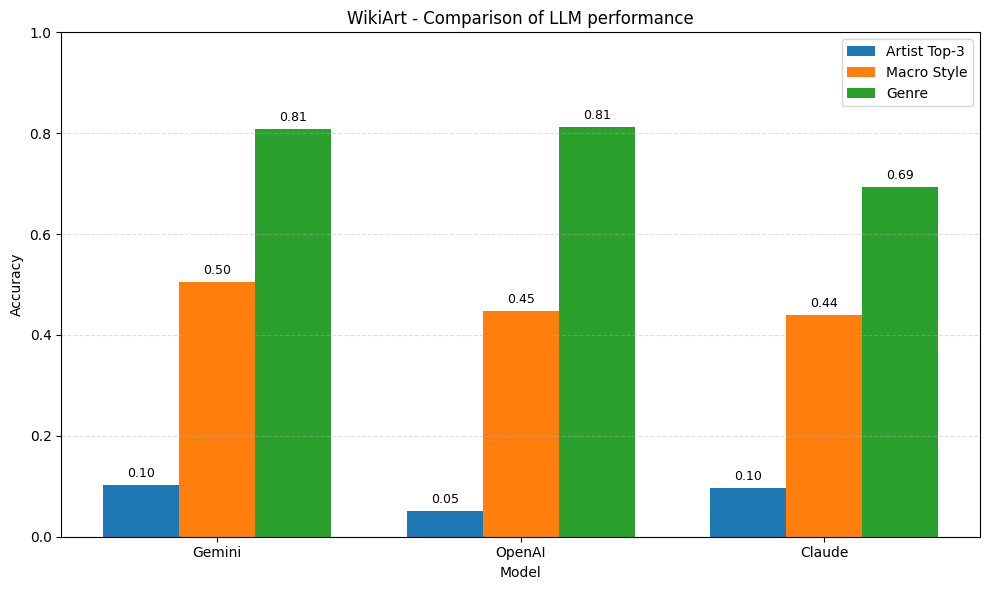

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = comparison_wikiart[[
    "model",
    "artist_top3_accuracy",
    "style_accuracy",
    "genre_accuracy"
]].copy()

models = plot_df["model"].tolist()
artist_vals = plot_df["artist_top3_accuracy"].tolist()
style_vals = plot_df["style_accuracy"].tolist()
genre_vals = plot_df["genre_accuracy"].tolist()

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10,6))

bars1 = ax.bar(x - width, artist_vals, width, label="Artist Top-3")
bars2 = ax.bar(x, style_vals, width, label="Macro Style")
bars3 = ax.bar(x + width, genre_vals, width, label="Genre")

ax.set_title("WikiArt - Comparison of LLM performance")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Model")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend()

for bars in [bars1, bars2, bars3]:
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 0.01, f"{h:.2f}",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
PARTE ARTQUEST ANALISI DEI RISULTATI
TUTTI E 3 GLI LLM

In [ ]:
df_artquest_ready = pd.read_csv("/content/artquest_second_prompt_READY.csv")

df_gemini = pd.read_csv("/content/results_structured_GEMINI.csv")
df_openai = pd.read_csv("/content/results_OPENIA_structured.csv")
df_claude = pd.read_csv("/content/results_ArtQuest_claude.csv")

print(df_artquest_ready.shape)
print(df_gemini.shape)
print(df_openai.shape)
print(df_claude.shape)

(13461, 7)
(4372, 20)
(3706, 20)
(3706, 9)


In [ ]:
common_images_artquest = (
    set(df_gemini["image"]) &
    set(df_openai["image"]) &
    set(df_claude["image"])
)

print("Opere analizzate da tutti e tre:", len(common_images_artquest))

Opere analizzate da tutti e tre: 3706


In [ ]:
df_gemini = df_gemini[df_gemini["image"].isin(common_images_artquest)]
df_openai = df_openai[df_openai["image"].isin(common_images_artquest)]
df_claude = df_claude[df_claude["image"].isin(common_images_artquest)]

In [ ]:
print("READY")
print(df_artquest_ready.columns)

print("\nGEMINI")
print(df_gemini.columns)

print("\nOPENAI")
print(df_openai.columns)

print("\nCLAUDE")
print(df_claude.columns)

READY
Index(['image', 'artist', 'school', 'technique', 'timeframe', 'type',
       'technique_macro'],
      dtype='object')

GEMINI
Index(['image', 'image_path', 'ok', 'error', 'model', 'timestamp_utc',
       'artist_1', 'artist_2', 'artist_3', 'macro_style', 'technique', 'genre',
       'school', 'historical_period', 'short_description',
       'wolfflin_linear_vs_painterly', 'wolfflin_plane_vs_recession',
       'wolfflin_closed_vs_open_form', 'wolfflin_multiplicity_vs_unity',
       'wolfflin_absolute_vs_relative_clarity'],
      dtype='object')

OPENAI
Index(['image', 'image_path', 'ok', 'error', 'model', 'timestamp_utc',
       'artist_1', 'artist_2', 'artist_3', 'macro_style', 'technique', 'genre',
       'school', 'historical_period', 'short_description',
       'wolfflin_linear_vs_painterly', 'wolfflin_plane_vs_recession',
       'wolfflin_closed_vs_open_form', 'wolfflin_multiplicity_vs_unity',
       'wolfflin_absolute_vs_relative_clarity'],
      dtype='object')

CLAUDE
Ind

In [ ]:
df_artquest_truth = df_artquest_ready.rename(columns={
    "artist": "true_artist",
    "school": "true_school",
    "technique": "true_technique",
    "timeframe": "true_timeframe",
    "type": "true_genre"
}).copy()

print(df_artquest_truth.shape)
display(df_artquest_truth.head())

(13461, 7)


,image,true_artist,true_school,true_technique,true_timeframe,true_genre,technique_macro
0,19337-14july.jpg,Childe HASSAM,american,oil,1851-1900,historical,oil
1,44058-8ambierl.jpg,Rogier van der WEYDEN,flemish,oil,1401-1450,religious,oil
2,38936-14abraha.jpg,Giovanni Battista TIEPOLO,italian,oil,1701-1750,religious,oil
3,43355-ambrose.jpg,Alvise VIVARINI,italian,oil,1451-1500,religious,oil
4,23980-sanluca3.jpg,Andrea MANTEGNA,italian,tempera,1451-1500,religious,tempera


In [ ]:
df_gem_art = df_artquest_truth.merge(df_gemini, on="image", how="inner")

print(df_gem_art.shape)
display(df_gem_art.head())
print(df_gem_art.columns.tolist())

(4186, 26)


,image,true_artist,true_school,true_technique,true_timeframe,true_genre,technique_macro,image_path,ok,error,...,technique,genre,school,historical_period,short_description,wolfflin_linear_vs_painterly,wolfflin_plane_vs_recession,wolfflin_closed_vs_open_form,wolfflin_multiplicity_vs_unity,wolfflin_absolute_vs_relative_clarity
0,19337-14july.jpg,Childe HASSAM,american,oil,1851-1900,historical,oil,/content/semart_subset/SemArt_subset/19337-14j...,False,NO_JSON_FOUND_IN_RESPONSE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,19337-14july.jpg,Childe HASSAM,american,oil,1851-1900,historical,oil,/content/semart_subset/SemArt_subset/19337-14j...,False,"Expecting ',' delimiter: line 15 column 4 (cha...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19337-14july.jpg,Childe HASSAM,american,oil,1851-1900,historical,oil,/content/semart_subset/SemArt_subset/19337-14j...,True,NaN,...,oil,landscape,french,1851-1900,"A vibrant landscape scene depicted with loose,...",5.0,5.0,5.0,5.0,5.0
3,43355-ambrose.jpg,Alvise VIVARINI,italian,oil,1451-1500,religious,oil,/content/semart_subset/SemArt_subset/43355-amb...,False,NO_JSON_FOUND_IN_RESPONSE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,43355-ambrose.jpg,Alvise VIVARINI,italian,oil,1451-1500,religious,oil,/content/semart_subset/SemArt_subset/43355-amb...,True,NaN,...,oil,religious,italian,1451-1500,"An Italian Renaissance altarpiece, 'Brera Mado...",1.0,4.0,2.0,4.0,1.0


['image', 'true_artist', 'true_school', 'true_technique', 'true_timeframe', 'true_genre', 'technique_macro', 'image_path', 'ok', 'error', 'model', 'timestamp_utc', 'artist_1', 'artist_2', 'artist_3', 'macro_style', 'technique', 'genre', 'school', 'historical_period', 'short_description', 'wolfflin_linear_vs_painterly', 'wolfflin_plane_vs_recession', 'wolfflin_closed_vs_open_form', 'wolfflin_multiplicity_vs_unity', 'wolfflin_absolute_vs_relative_clarity']


In [ ]:
df_gem_art_valid = df_gem_art[df_gem_art["ok"] == True].copy()

print("Totale righe dopo merge:", len(df_gem_art))
print("Righe valide Gemini:", len(df_gem_art_valid))

Totale righe dopo merge: 4186
Righe valide Gemini: 3706


In [ ]:
def gemini_artquest_artist_top3_correct(row):
    true_tokens = extract_tokens(row["true_artist"])

    preds = [
        row["artist_1"],
        row["artist_2"],
        row["artist_3"]
    ]

    for p in preds:
        pred_tokens = extract_tokens(p)
        if true_tokens == pred_tokens:
            return True

    return False

df_gem_art_valid["artist_top3_correct"] = df_gem_art_valid.apply(
    gemini_artquest_artist_top3_correct, axis=1
)

In [ ]:
artist_correct_n = int(df_gem_art_valid["artist_top3_correct"].sum())
artist_wrong_n = int((~df_gem_art_valid["artist_top3_correct"]).sum())
artist_acc = df_gem_art_valid["artist_top3_correct"].mean()

print("GEMINI - ARTQUEST - ARTIST TOP3")
print("Totale opere valide:", len(df_gem_art_valid))
print("Corretti:", artist_correct_n)
print("Sbagliati:", artist_wrong_n)
print(f"Accuracy: {artist_acc*100:.2f}%")

GEMINI - ARTQUEST - ARTIST TOP3
Totale opere valide: 3706
Corretti: 511
Sbagliati: 3195
Accuracy: 13.79%


In [ ]:
errors_gem_art = df_gem_art_valid[df_gem_art_valid["artist_top3_correct"] == False]

errors_gem_art[[
    "image",
    "true_artist",
    "artist_1",
    "artist_2",
    "artist_3"
]].head(20)

,image,true_artist,artist_1,artist_2,artist_3
2,19337-14july.jpg,Childe HASSAM,Claude Monet,Camille Pissarro,Édouard Manet
4,43355-ambrose.jpg,Alvise VIVARINI,Piero della Francesca,Andrea Mantegna,Giovanni Bellini
8,20692-bowyer.jpg,Cornelius the Elder JONSON VAN CEULEN,Peter Lely,John Michael Wright,Simon Pietersz Verelst
9,19873-1darmst.jpg,Hans the Younger HOLBEIN,Hans Memling,Rogier van der Weyden,Dieric Bouts
13,04589-temptati.jpg,Giovanni BILIVERT,Tintoretto,Paolo Veronese,Jacopo Bassano
15,24485-01view.jpg,MASO DI BANCO,Giotto di Bondone,Cimabue,Duccio di Buoninsegna
16,03093-calvary.jpg,Peeter BALTENS,Pieter Bruegel the Elder,Jan Brueghel the Elder,Joachim Patinir
18,20320-mountain.jpg,Jan Baptist HUYSMANS,Jan Both,Jacob van Ruisdael,Meindert Hobbema
19,08705-pieta.jpg,Enguerrand CHARONTON,Jaume Huguet,Fra Angelico,Simone Martini
22,07640-descent.jpg,Bartolomé CARDUCHO,Caravaggio,Annibale Carracci,Lodovico Carracci


In [ ]:
most_wrong_artists_gem = (
    errors_gem_art["true_artist"]
    .value_counts()
    .reset_index()
)

most_wrong_artists_gem.columns = ["artist", "n_errors"]

display(most_wrong_artists_gem.head(20))

,artist,n_errors
0,REMBRANDT Harmenszoon van Rijn,55
1,TIZIANO Vecellio,50
2,RAFFAELLO Sanzio,44
3,Italian UNKNOWN MASTER,31
4,Francisco de GOYA Y LUCIENTES,28
5,MICHELANGELO Buonarroti,23
6,Lorenzo LOTTO,22
7,Diego Rodriguez de Silva y VELÁZQUEZ,21
8,Paolo VERONESE,16
9,Flemish UNKNOWN MASTER,16


In [ ]:
df_gem_art_valid["genre_correct"] = (
    df_gem_art_valid["true_genre"].astype(str).str.strip().str.lower()
    ==
    df_gem_art_valid["genre"].astype(str).str.strip().str.lower()
)

genre_correct_n = int(df_gem_art_valid["genre_correct"].sum())
genre_wrong_n = int((~df_gem_art_valid["genre_correct"]).sum())
genre_acc = df_gem_art_valid["genre_correct"].mean()

print("GEMINI - ARTQUEST - GENRE")
print("Totale opere valide:", len(df_gem_art_valid))
print("Corretti:", genre_correct_n)
print("Sbagliati:", genre_wrong_n)
print(f"Accuracy: {genre_acc*100:.2f}%")

GEMINI - ARTQUEST - GENRE
Totale opere valide: 3706
Corretti: 3047
Sbagliati: 659
Accuracy: 82.22%


In [ ]:
genre_stats_gem = (
    df_gem_art_valid.groupby("true_genre")
    .agg(
        n_opere=("image", "count"),
        correct=("genre_correct", "sum")
    )
    .reset_index()
)

genre_stats_gem["accuracy"] = genre_stats_gem["correct"] / genre_stats_gem["n_opere"]

genre_stats_gem = genre_stats_gem.sort_values(by="accuracy", ascending=False)

print("GENERI PIÙ CORRETTI")
display(genre_stats_gem.head(10))

print("\nGENERI MENO CORRETTI")
display(genre_stats_gem.tail(10))

GENERI PIÙ CORRETTI


,true_genre,n_opere,correct,accuracy
8,still-life,192,178,0.927083
6,portrait,651,603,0.926267
7,religious,1455,1320,0.907216
0,genre,295,249,0.844068
3,landscape,434,316,0.728111
1,historical,115,80,0.695652
4,mythological,389,260,0.668380
2,interior,98,39,0.397959
5,other,70,2,0.028571
9,study,7,0,0.000000



GENERI MENO CORRETTI


,true_genre,n_opere,correct,accuracy
8,still-life,192,178,0.927083
6,portrait,651,603,0.926267
7,religious,1455,1320,0.907216
0,genre,295,249,0.844068
3,landscape,434,316,0.728111
1,historical,115,80,0.695652
4,mythological,389,260,0.668380
2,interior,98,39,0.397959
5,other,70,2,0.028571
9,study,7,0,0.000000


In [ ]:
genre_pred_distribution = (
    df_gem_art_valid["genre"]
    .value_counts()
    .reset_index()
)

genre_pred_distribution.columns = ["predicted_genre", "count"]

display(genre_pred_distribution.head(15))

,predicted_genre,count
0,religious,1418
1,portrait,656
2,genre,468
3,mythological,351
4,landscape,332
5,historical,231
6,still-life,183
7,interior,56
8,other,11


In [ ]:
df_gem_art_valid["technique_correct"] = (
    df_gem_art_valid["true_technique"].astype(str).str.strip().str.lower()
    ==
    df_gem_art_valid["technique"].astype(str).str.strip().str.lower()
)

technique_correct_n = int(df_gem_art_valid["technique_correct"].sum())
technique_wrong_n = int((~df_gem_art_valid["technique_correct"]).sum())
technique_acc = df_gem_art_valid["technique_correct"].mean()

print("GEMINI - ARTQUEST - TECHNIQUE")
print("Totale opere valide:", len(df_gem_art_valid))
print("Corretti:", technique_correct_n)
print("Sbagliati:", technique_wrong_n)
print(f"Accuracy: {technique_acc*100:.2f}%")

GEMINI - ARTQUEST - TECHNIQUE
Totale opere valide: 3706
Corretti: 3479
Sbagliati: 227
Accuracy: 93.87%


In [ ]:
technique_stats_gem = (
    df_gem_art_valid.groupby("true_technique")
    .agg(
        n_opere=("image", "count"),
        correct=("technique_correct", "sum")
    )
    .reset_index()
)

technique_stats_gem["accuracy"] = technique_stats_gem["correct"] / technique_stats_gem["n_opere"]

technique_stats_gem = technique_stats_gem.sort_values(by="accuracy", ascending=False)

print("TECNICHE PIÙ CORRETTE")
display(technique_stats_gem.head(10))

print("\nTECNICHE MENO CORRETTE")
display(technique_stats_gem.tail(10))

TECNICHE PIÙ CORRETTE


,true_technique,n_opere,correct,accuracy
4,oil,2755,2683,0.973866
2,fresco,553,498,0.900542
0,drawing,6,5,0.833333
6,tempera,357,277,0.775910
5,pastel,18,11,0.611111
7,watercolour,15,5,0.333333
3,mixed,1,0,0.000000
1,encaustic,1,0,0.000000



TECNICHE MENO CORRETTE


,true_technique,n_opere,correct,accuracy
4,oil,2755,2683,0.973866
2,fresco,553,498,0.900542
0,drawing,6,5,0.833333
6,tempera,357,277,0.775910
5,pastel,18,11,0.611111
7,watercolour,15,5,0.333333
3,mixed,1,0,0.000000
1,encaustic,1,0,0.000000


In [ ]:
df_gem_art_valid["school_correct"] = (
    df_gem_art_valid["true_school"].astype(str).str.strip().str.lower()
    ==
    df_gem_art_valid["school"].astype(str).str.strip().str.lower()
)

school_correct_n = int(df_gem_art_valid["school_correct"].sum())
school_wrong_n = int((~df_gem_art_valid["school_correct"]).sum())
school_acc = df_gem_art_valid["school_correct"].mean()

print("GEMINI - ARTQUEST - SCHOOL")
print("Totale opere valide:", len(df_gem_art_valid))
print("Corretti:", school_correct_n)
print("Sbagliati:", school_wrong_n)
print(f"Accuracy: {school_acc*100:.2f}%")

GEMINI - ARTQUEST - SCHOOL
Totale opere valide: 3706
Corretti: 2472
Sbagliati: 1234
Accuracy: 66.70%


In [ ]:
school_stats_gem = (
    df_gem_art_valid.groupby("true_school")
    .agg(
        n_opere=("image", "count"),
        correct=("school_correct", "sum")
    )
    .reset_index()
)

school_stats_gem["accuracy"] = school_stats_gem["correct"] / school_stats_gem["n_opere"]

school_stats_gem = school_stats_gem.sort_values(by="accuracy", ascending=False)

print("SCUOLE PIÙ CORRETTE")
display(school_stats_gem.head(10))

print("\nSCUOLE MENO CORRETTE")
display(school_stats_gem.tail(10))

SCUOLE PIÙ CORRETTE


,true_school,n_opere,correct,accuracy
14,italian,1671,1445,0.864752
7,english,82,58,0.707317
6,dutch,595,417,0.700840
9,french,378,222,0.587302
0,american,15,8,0.533333
22,spanish,165,79,0.478788
11,greek,11,5,0.454545
8,flemish,363,150,0.413223
20,russian,18,7,0.388889
15,netherlandish,28,10,0.357143



SCUOLE MENO CORRETTE


,true_school,n_opere,correct,accuracy
1,austrian,41,2,0.04878
3,bohemian,4,0,0.00000
2,belgian,4,0,0.00000
12,hungarian,39,0,0.00000
13,irish,3,0,0.00000
17,other,6,0,0.00000
19,portuguese,1,0,0.00000
18,polish,4,0,0.00000
23,swedish,5,0,0.00000
24,swiss,16,0,0.00000


In [ ]:
df_gem_art_valid["timeframe_correct"] = (
    df_gem_art_valid["true_timeframe"].astype(str).str.strip().str.lower()
    ==
    df_gem_art_valid["historical_period"].astype(str).str.strip().str.lower()
)

timeframe_correct_n = int(df_gem_art_valid["timeframe_correct"].sum())
timeframe_wrong_n = int((~df_gem_art_valid["timeframe_correct"]).sum())
timeframe_acc = df_gem_art_valid["timeframe_correct"].mean()

print("GEMINI - ARTQUEST - TIMEFRAME")
print("Totale opere valide:", len(df_gem_art_valid))
print("Corretti:", timeframe_correct_n)
print("Sbagliati:", timeframe_wrong_n)
print(f"Accuracy: {timeframe_acc*100:.2f}%")

GEMINI - ARTQUEST - TIMEFRAME
Totale opere valide: 3706
Corretti: 2077
Sbagliati: 1629
Accuracy: 56.04%


In [ ]:
timeframe_stats_gem = (
    df_gem_art_valid.groupby("true_timeframe")
    .agg(
        n_opere=("image", "count"),
        correct=("timeframe_correct", "sum")
    )
    .reset_index()
)

timeframe_stats_gem["accuracy"] = timeframe_stats_gem["correct"] / timeframe_stats_gem["n_opere"]

timeframe_stats_gem = timeframe_stats_gem.sort_values(by="accuracy", ascending=False)

print("PERIODI PIÙ CORRETTI")
display(timeframe_stats_gem.head(10))

print("\nPERIODI MENO CORRETTI")
display(timeframe_stats_gem.tail(10))

PERIODI PIÙ CORRETTI


,true_timeframe,n_opere,correct,accuracy
21,1851-1900,171,150,0.877193
10,1301-1350,116,87,0.750000
9,1251-1300,24,17,0.708333
20,1801-1850,222,142,0.639640
16,1601-1650,756,473,0.625661
19,1751-1800,258,160,0.620155
14,1501-1550,526,311,0.591255
13,1451-1500,333,186,0.558559
12,1401-1450,159,79,0.496855
17,1651-1700,468,229,0.489316



PERIODI MENO CORRETTI


,true_timeframe,n_opere,correct,accuracy
6,1101-1150,3,1,0.333333
8,1201-1250,4,1,0.250000
11,1351-1400,79,2,0.025316
4,1001-1050,1,0,0.000000
5,1051-1100,3,0,0.000000
2,0851-0900,2,0,0.000000
1,0801-0850,1,0,0.000000
0,0751-0800,1,0,0.000000
3,0951-1000,1,0,0.000000
7,1151-1200,5,0,0.000000


In [ ]:
results_gemini_artquest = pd.DataFrame([{
    "model": "Gemini",
    "n_valid": len(df_gem_art_valid),

    "artist_top3_correct": artist_correct_n,
    "artist_top3_wrong": artist_wrong_n,
    "artist_top3_accuracy": artist_acc,

    "genre_correct": genre_correct_n,
    "genre_wrong": genre_wrong_n,
    "genre_accuracy": genre_acc,

    "technique_correct": technique_correct_n,
    "technique_wrong": technique_wrong_n,
    "technique_accuracy": technique_acc,

    "school_correct": school_correct_n,
    "school_wrong": school_wrong_n,
    "school_accuracy": school_acc,

    "timeframe_correct": timeframe_correct_n,
    "timeframe_wrong": timeframe_wrong_n,
    "timeframe_accuracy": timeframe_acc
}])

results_gemini_artquest

,model,n_valid,artist_top3_correct,artist_top3_wrong,artist_top3_accuracy,genre_correct,genre_wrong,genre_accuracy,technique_correct,technique_wrong,technique_accuracy,school_correct,school_wrong,school_accuracy,timeframe_correct,timeframe_wrong,timeframe_accuracy
0,Gemini,3706,511,3195,0.137885,3047,659,0.82218,3479,227,0.938748,2472,1234,0.667026,2077,1629,0.560443


In [ ]:
confusion_genre = pd.crosstab(
    df_gem_art_valid["true_genre"],
    df_gem_art_valid["genre"]
)

display(confusion_genre)

genre,genre,historical,interior,landscape,mythological,other,portrait,religious,still-life
true_genre,,,,,,,,,
genre,249,7,4,2,11,1,16,4,1
historical,11,80,1,4,9,0,4,6,0
interior,31,8,39,0,4,1,0,15,0
landscape,78,13,2,316,13,1,0,9,2
mythological,25,40,5,1,260,2,12,44,0
other,20,15,2,2,13,2,7,8,1
portrait,21,9,1,1,7,1,603,8,0
religious,21,59,2,4,33,3,12,1320,1
still-life,11,0,0,0,1,0,0,2,178


In [ ]:
ARTQUEST PARTE OPENAI

In [ ]:
df_artquest_truth = df_artquest_ready.rename(columns={
    "artist": "true_artist",
    "school": "true_school",
    "technique": "true_technique",
    "timeframe": "true_timeframe",
    "type": "true_genre"
}).copy()

In [ ]:
df_open_art = df_artquest_truth.merge(
    df_openai,
    on="image",
    how="inner"
)

print("Totale righe dopo merge:", len(df_open_art))
display(df_open_art.head())

Totale righe dopo merge: 3706


,image,true_artist,true_school,true_technique,true_timeframe,true_genre,technique_macro,image_path,ok,error,...,technique,genre,school,historical_period,short_description,wolfflin_linear_vs_painterly,wolfflin_plane_vs_recession,wolfflin_closed_vs_open_form,wolfflin_multiplicity_vs_unity,wolfflin_absolute_vs_relative_clarity
0,19337-14july.jpg,Childe HASSAM,american,oil,1851-1900,historical,oil,/content/semart_subset/SemArt_subset/19337-14j...,True,NaN,...,oil,genre,french,1851-1900,A busy urban street scene in Paris with crowds...,4,3,4,3,4
1,43355-ambrose.jpg,Alvise VIVARINI,italian,oil,1451-1500,religious,oil,/content/semart_subset/SemArt_subset/43355-amb...,True,NaN,...,oil,religious,italian,1501-1550,A Renaissance religious scene with symmetrical...,1,5,1,5,1
2,12175-cro_f_2.jpg,DUCCIO di Buoninsegna,italian,tempera,1301-1350,religious,tempera,/content/semart_subset/SemArt_subset/12175-cro...,True,NaN,...,tempera,religious,italian,1301-1350,"Tempera painting featuring a kneeling figure, ...",1,2,1,2,1
3,15171-coronat.jpg,GENTILE DA FABRIANO,italian,tempera,1351-1400,religious,tempera,/content/semart_subset/SemArt_subset/15171-cor...,True,NaN,...,tempera,religious,italian,1401-1450,A Gothic religious altarpiece with multiple ta...,1,2,1,2,1
4,20692-bowyer.jpg,Cornelius the Elder JONSON VAN CEULEN,flemish,oil,1601-1650,portrait,oil,/content/semart_subset/SemArt_subset/20692-bow...,True,NaN,...,oil,portrait,flemish,1601-1650,Oval framed portrait of a woman with curled ha...,2,4,2,4,2


In [ ]:
df_open_art_valid = df_open_art[df_open_art["ok"] == True].copy()

print("Totale dopo merge:", len(df_open_art))
print("Righe valide OpenAI:", len(df_open_art_valid))
print(f"Valid rate: {len(df_open_art_valid)/len(df_open_art)*100:.2f}%")

Totale dopo merge: 3706
Righe valide OpenAI: 3706
Valid rate: 100.00%


In [ ]:
def openai_artquest_artist_top3_correct(row):
    true_tokens = extract_tokens(row["true_artist"])

    preds = [
        row["artist_1"],
        row["artist_2"],
        row["artist_3"]
    ]

    for p in preds:
        pred_tokens = extract_tokens(p)
        if true_tokens == pred_tokens:
            return True

    return False

df_open_art_valid["artist_top3_correct"] = df_open_art_valid.apply(
    openai_artquest_artist_top3_correct, axis=1
)

In [ ]:
artist_correct_n = int(df_open_art_valid["artist_top3_correct"].sum())
artist_wrong_n = int((~df_open_art_valid["artist_top3_correct"]).sum())
artist_acc = df_open_art_valid["artist_top3_correct"].mean()

print("OPENAI - ARTQUEST - ARTIST TOP3")
print("Totale opere valide:", len(df_open_art_valid))
print("Corretti:", artist_correct_n)
print("Sbagliati:", artist_wrong_n)
print(f"Accuracy: {artist_acc*100:.2f}%")

OPENAI - ARTQUEST - ARTIST TOP3
Totale opere valide: 3706
Corretti: 421
Sbagliati: 3285
Accuracy: 11.36%


In [ ]:
errors_open_art = df_open_art_valid[df_open_art_valid["artist_top3_correct"] == False]

errors_open_art[[
    "image",
    "true_artist",
    "artist_1",
    "artist_2",
    "artist_3"
]].head(20)

,image,true_artist,artist_1,artist_2,artist_3
0,19337-14july.jpg,Childe HASSAM,Camille Pissarro,Alfred Sisley,Gustave Caillebotte
1,43355-ambrose.jpg,Alvise VIVARINI,Raphael,Pietro Perugino,Andrea del Sarto
4,20692-bowyer.jpg,Cornelius the Elder JONSON VAN CEULEN,Anthony van Dyck,Peter Lely,Gerrit van Honthorst
5,19873-1darmst.jpg,Hans the Younger HOLBEIN,Hans Memling,Rogier van der Weyden,Jan van Eyck
6,04589-temptati.jpg,Giovanni BILIVERT,Nicolas Poussin,Guido Reni,Simon Vouet
7,36582-paolo_f1.jpg,Ary SCHEFFER,François Gérard,Anne-Louis Girodet,Jacques-Louis David
8,24485-01view.jpg,MASO DI BANCO,Giotto di Bondone,Cimabue,Pietro Lorenzetti
9,03093-calvary.jpg,Peeter BALTENS,Pieter Bruegel the Elder,Joos de Momper,Pieter Brueghel the Younger
10,20320-mountain.jpg,Jan Baptist HUYSMANS,Jacob van Ruisdael,Aelbert Cuyp,Meindert Hobbema
11,08705-pieta.jpg,Enguerrand CHARONTON,Andrea Mantegna,Giotto di Bondone,Fra Angelico


In [ ]:
most_wrong_artists_open = (
    errors_open_art["true_artist"]
    .value_counts()
    .reset_index()
)

most_wrong_artists_open.columns = ["artist", "n_errors"]

display(most_wrong_artists_open.head(20))

,artist,n_errors
0,REMBRANDT Harmenszoon van Rijn,53
1,TIZIANO Vecellio,50
2,RAFFAELLO Sanzio,44
3,Italian UNKNOWN MASTER,32
4,Francisco de GOYA Y LUCIENTES,28
5,Diego Rodriguez de Silva y VELÁZQUEZ,20
6,Domenico GHIRLANDAIO,16
7,Lorenzo LOTTO,16
8,Flemish UNKNOWN MASTER,15
9,Jacob Isaackszon van RUISDAEL,15


In [ ]:
df_open_art_valid["genre_correct"] = (
    df_open_art_valid["true_genre"].astype(str).str.strip().str.lower()
    ==
    df_open_art_valid["genre"].astype(str).str.strip().str.lower()
)

genre_correct_n = int(df_open_art_valid["genre_correct"].sum())
genre_wrong_n = int((~df_open_art_valid["genre_correct"]).sum())
genre_acc = df_open_art_valid["genre_correct"].mean()

print("OPENAI - ARTQUEST - GENRE")
print("Totale opere valide:", len(df_open_art_valid))
print("Corretti:", genre_correct_n)
print("Sbagliati:", genre_wrong_n)
print(f"Accuracy: {genre_acc*100:.2f}%")

OPENAI - ARTQUEST - GENRE
Totale opere valide: 3706
Corretti: 2831
Sbagliati: 875
Accuracy: 76.39%


In [ ]:
df_open_art_valid["technique_correct"] = (
    df_open_art_valid["true_technique"].astype(str).str.strip().str.lower()
    ==
    df_open_art_valid["technique"].astype(str).str.strip().str.lower()
)

technique_correct_n = int(df_open_art_valid["technique_correct"].sum())
technique_wrong_n = int((~df_open_art_valid["technique_correct"]).sum())
technique_acc = df_open_art_valid["technique_correct"].mean()

print("OPENAI - ARTQUEST - TECHNIQUE")
print("Totale opere valide:", len(df_open_art_valid))
print("Corretti:", technique_correct_n)
print("Sbagliati:", technique_wrong_n)
print(f"Accuracy: {technique_acc*100:.2f}%")

OPENAI - ARTQUEST - TECHNIQUE
Totale opere valide: 3706
Corretti: 3487
Sbagliati: 219
Accuracy: 94.09%


In [ ]:
df_open_art_valid["school_correct"] = (
    df_open_art_valid["true_school"].astype(str).str.strip().str.lower()
    ==
    df_open_art_valid["school"].astype(str).str.strip().str.lower()
)

school_correct_n = int(df_open_art_valid["school_correct"].sum())
school_wrong_n = int((~df_open_art_valid["school_correct"]).sum())
school_acc = df_open_art_valid["school_correct"].mean()

print("OPENAI - ARTQUEST - SCHOOL")
print("Totale opere valide:", len(df_open_art_valid))
print("Corretti:", school_correct_n)
print("Sbagliati:", school_wrong_n)
print(f"Accuracy: {school_acc*100:.2f}%")

OPENAI - ARTQUEST - SCHOOL
Totale opere valide: 3706
Corretti: 2278
Sbagliati: 1428
Accuracy: 61.47%


In [ ]:
df_open_art_valid["timeframe_correct"] = (
    df_open_art_valid["true_timeframe"].astype(str).str.strip().str.lower()
    ==
    df_open_art_valid["historical_period"].astype(str).str.strip().str.lower()
)

timeframe_correct_n = int(df_open_art_valid["timeframe_correct"].sum())
timeframe_wrong_n = int((~df_open_art_valid["timeframe_correct"]).sum())
timeframe_acc = df_open_art_valid["timeframe_correct"].mean()

print("OPENAI - ARTQUEST - TIMEFRAME")
print("Totale opere valide:", len(df_open_art_valid))
print("Corretti:", timeframe_correct_n)
print("Sbagliati:", timeframe_wrong_n)
print(f"Accuracy: {timeframe_acc*100:.2f}%")

OPENAI - ARTQUEST - TIMEFRAME
Totale opere valide: 3706
Corretti: 1873
Sbagliati: 1833
Accuracy: 50.54%


In [ ]:
results_openai_artquest = pd.DataFrame([{
    "model": "OpenAI",
    "n_valid": len(df_open_art_valid),

    "artist_top3_correct": artist_correct_n,
    "artist_top3_wrong": artist_wrong_n,
    "artist_top3_accuracy": artist_acc,

    "genre_correct": genre_correct_n,
    "genre_wrong": genre_wrong_n,
    "genre_accuracy": genre_acc,

    "technique_correct": technique_correct_n,
    "technique_wrong": technique_wrong_n,
    "technique_accuracy": technique_acc,

    "school_correct": school_correct_n,
    "school_wrong": school_wrong_n,
    "school_accuracy": school_acc,

    "timeframe_correct": timeframe_correct_n,
    "timeframe_wrong": timeframe_wrong_n,
    "timeframe_accuracy": timeframe_acc
}])

results_openai_artquest

,model,n_valid,artist_top3_correct,artist_top3_wrong,artist_top3_accuracy,genre_correct,genre_wrong,genre_accuracy,technique_correct,technique_wrong,technique_accuracy,school_correct,school_wrong,school_accuracy,timeframe_correct,timeframe_wrong,timeframe_accuracy
0,OpenAI,3706,421,3285,0.1136,2831,875,0.763896,3487,219,0.940907,2278,1428,0.614679,1873,1833,0.505397


In [ ]:
genre_stats_open = (
    df_open_art_valid.groupby("true_genre")
    .agg(
        n_opere=("image", "count"),
        correct=("genre_correct", "sum")
    )
    .reset_index()
)

genre_stats_open["accuracy"] = genre_stats_open["correct"] / genre_stats_open["n_opere"]
genre_stats_open = genre_stats_open.sort_values(by="accuracy", ascending=False)

print("GENERI PIÙ CORRETTI")
display(genre_stats_open.head(10))

print("\nGENERI MENO CORRETTI")
display(genre_stats_open.tail(10))

GENERI PIÙ CORRETTI


,true_genre,n_opere,correct,accuracy
6,portrait,651,622,0.955453
8,still-life,192,180,0.937500
3,landscape,434,375,0.864055
7,religious,1455,1085,0.745704
0,genre,295,217,0.735593
1,historical,115,72,0.626087
4,mythological,389,222,0.570694
2,interior,98,49,0.500000
5,other,70,9,0.128571
9,study,7,0,0.000000



GENERI MENO CORRETTI


,true_genre,n_opere,correct,accuracy
6,portrait,651,622,0.955453
8,still-life,192,180,0.937500
3,landscape,434,375,0.864055
7,religious,1455,1085,0.745704
0,genre,295,217,0.735593
1,historical,115,72,0.626087
4,mythological,389,222,0.570694
2,interior,98,49,0.500000
5,other,70,9,0.128571
9,study,7,0,0.000000


In [ ]:
technique_stats_open = (
    df_open_art_valid.groupby("true_technique")
    .agg(
        n_opere=("image", "count"),
        correct=("technique_correct", "sum")
    )
    .reset_index()
)

technique_stats_open["accuracy"] = technique_stats_open["correct"] / technique_stats_open["n_opere"]
technique_stats_open = technique_stats_open.sort_values(by="accuracy", ascending=False)

print("TECNICHE PIÙ CORRETTE")
display(technique_stats_open.head(10))

print("\nTECNICHE MENO CORRETTE")
display(technique_stats_open.tail(10))

TECNICHE PIÙ CORRETTE


,true_technique,n_opere,correct,accuracy
4,oil,2755,2664,0.966969
2,fresco,553,497,0.898734
6,tempera,357,307,0.859944
0,drawing,6,5,0.833333
5,pastel,18,11,0.611111
7,watercolour,15,3,0.200000
3,mixed,1,0,0.000000
1,encaustic,1,0,0.000000



TECNICHE MENO CORRETTE


,true_technique,n_opere,correct,accuracy
4,oil,2755,2664,0.966969
2,fresco,553,497,0.898734
6,tempera,357,307,0.859944
0,drawing,6,5,0.833333
5,pastel,18,11,0.611111
7,watercolour,15,3,0.200000
3,mixed,1,0,0.000000
1,encaustic,1,0,0.000000


In [ ]:
school_stats_open = (
    df_open_art_valid.groupby("true_school")
    .agg(
        n_opere=("image", "count"),
        correct=("school_correct", "sum")
    )
    .reset_index()
)

school_stats_open["accuracy"] = school_stats_open["correct"] / school_stats_open["n_opere"]
school_stats_open = school_stats_open.sort_values(by="accuracy", ascending=False)

print("SCUOLE PIÙ CORRETTE")
display(school_stats_open.head(10))

print("\nSCUOLE MENO CORRETTE")
display(school_stats_open.tail(10))

SCUOLE PIÙ CORRETTE


,true_school,n_opere,correct,accuracy
14,italian,1671,1352,0.809096
6,dutch,595,366,0.615126
9,french,378,223,0.589947
7,english,82,47,0.573171
22,spanish,165,78,0.472727
8,flemish,363,140,0.385675
0,american,15,5,0.333333
20,russian,18,5,0.277778
10,german,210,52,0.247619
11,greek,11,2,0.181818



SCUOLE MENO CORRETTE


,true_school,n_opere,correct,accuracy
3,bohemian,4,0,0.0
12,hungarian,39,0,0.0
16,norwegian,4,0,0.0
13,irish,3,0,0.0
18,polish,4,0,0.0
17,other,6,0,0.0
19,portuguese,1,0,0.0
21,scottish,15,0,0.0
23,swedish,5,0,0.0
24,swiss,16,0,0.0


In [ ]:
timeframe_stats_open = (
    df_open_art_valid.groupby("true_timeframe")
    .agg(
        n_opere=("image", "count"),
        correct=("timeframe_correct", "sum")
    )
    .reset_index()
)

timeframe_stats_open["accuracy"] = timeframe_stats_open["correct"] / timeframe_stats_open["n_opere"]
timeframe_stats_open = timeframe_stats_open.sort_values(by="accuracy", ascending=False)

print("PERIODI PIÙ CORRETTI")
display(timeframe_stats_open.head(10))

print("\nPERIODI MENO CORRETTI")
display(timeframe_stats_open.tail(10))

PERIODI PIÙ CORRETTI


,true_timeframe,n_opere,correct,accuracy
16,1601-1650,756,631,0.834656
21,1851-1900,171,134,0.783626
10,1301-1350,116,90,0.775862
20,1801-1850,222,126,0.567568
14,1501-1550,526,272,0.517110
13,1451-1500,333,158,0.474474
19,1751-1800,258,109,0.422481
12,1401-1450,159,63,0.396226
15,1551-1600,296,115,0.388514
9,1251-1300,24,7,0.291667



PERIODI MENO CORRETTI


,true_timeframe,n_opere,correct,accuracy
17,1651-1700,468,92,0.196581
11,1351-1400,79,2,0.025316
5,1051-1100,3,0,0.000000
4,1001-1050,1,0,0.000000
3,0951-1000,1,0,0.000000
2,0851-0900,2,0,0.000000
1,0801-0850,1,0,0.000000
0,0751-0800,1,0,0.000000
7,1151-1200,5,0,0.000000
6,1101-1150,3,0,0.000000


In [ ]:
PARTE ARTQUEST  claude analisi risultati

In [ ]:
df_claude[["image", "pred"]].head(5)

,image,pred
0,19337-14july.jpg,"{'artist_guess': ['Childe Hassam', 'Claude Mon..."
1,43355-ambrose.jpg,"{'artist_guess': ['Luca Signorelli', 'Perugino..."
2,12175-cro_f_2.jpg,"{'artist_guess': ['Duccio di Buoninsegna', 'Gi..."
3,15171-coronat.jpg,"{'artist_guess': ['Gentile da Fabriano', 'Lore..."
4,20692-bowyer.jpg,"{'artist_guess': ['Francisco Goya', 'Vicente L..."


In [ ]:
import ast
import pandas as pd

def parse_claude_pred(text):
    if pd.isna(text):
        return {}

    s = str(text).strip()

    try:
        data = ast.literal_eval(s)
        if isinstance(data, dict):
            return data
        return {}
    except Exception:
        return {}

In [ ]:
import ast
import pandas as pd

def parse_claude_pred(text):
    if pd.isna(text):
        return {}

    s = str(text).strip()

    try:
        data = ast.literal_eval(s)
        if isinstance(data, dict):
            return data
        return {}
    except Exception:
        return {}

rows = []

for _, row in df_claude.iterrows():
    parsed = parse_claude_pred(row["pred"])

    artist_guess = parsed.get("artist_guess", [None, None, None])
    if not isinstance(artist_guess, list):
        artist_guess = [None, None, None]

    wol = parsed.get("wolfflin_principles", {})
    if not isinstance(wol, dict):
        wol = {}

    rows.append({
        "image": row["image"],

        "artist_1": artist_guess[0] if len(artist_guess) > 0 else None,
        "artist_2": artist_guess[1] if len(artist_guess) > 1 else None,
        "artist_3": artist_guess[2] if len(artist_guess) > 2 else None,

        "macro_style": parsed.get("macro_style"),
        "technique": parsed.get("technique"),
        "genre": parsed.get("genre"),
        "school": parsed.get("school"),
        "historical_period": parsed.get("historical_period"),
        "short_description": parsed.get("short_description"),

        "wolfflin_linear_vs_painterly": wol.get("linear_vs_painterly"),
        "wolfflin_plane_vs_recession": wol.get("plane_vs_recession"),
        "wolfflin_closed_vs_open_form": wol.get("closed_vs_open_form"),
        "wolfflin_multiplicity_vs_unity": wol.get("multiplicity_vs_unity"),
        "wolfflin_absolute_vs_relative_clarity": wol.get("absolute_vs_relative_clarity"),

        "ok": row["ok"],
        "error": row["error"],
        "model": row["model"]
    })

df_claude_parsed = pd.DataFrame(rows)

print(df_claude_parsed.shape)
display(df_claude_parsed.head())
print(df_claude_parsed.columns.tolist())

(3706, 18)


,image,artist_1,artist_2,artist_3,macro_style,technique,genre,school,historical_period,short_description,wolfflin_linear_vs_painterly,wolfflin_plane_vs_recession,wolfflin_closed_vs_open_form,wolfflin_multiplicity_vs_unity,wolfflin_absolute_vs_relative_clarity,ok,error,model
0,19337-14july.jpg,Childe Hassam,Claude Monet,Pierre-Auguste Renoir,Impressionism,oil,historical,american,1851-1900,A bustling Parisian street scene with French f...,4,4,4,2,4,True,NaN,claude-haiku-4-5
1,43355-ambrose.jpg,Luca Signorelli,Perugino,Pinturicchio,Renaissance,oil,religious,italian,1451-1500,Renaissance religious scene depicting a bishop...,2,4,2,4,2,True,NaN,claude-haiku-4-5
2,12175-cro_f_2.jpg,Duccio di Buoninsegna,Giotto di Bondone,Cimabue,Medieval,tempera,religious,italian,1301-1350,Two-panel religious narrative scene depicting ...,2,2,2,4,2,True,NaN,claude-haiku-4-5
3,15171-coronat.jpg,Gentile da Fabriano,Lorenzo Monaco,Giotto di Bondone,Medieval,tempera,religious,italian,1401-1450,Gothic polyptych altarpiece with gold leaf bac...,2,2,1,2,2,True,NaN,claude-haiku-4-5
4,20692-bowyer.jpg,Francisco Goya,Vicente López,Mariano Salvador Maella,Neoclassicism / Classicism,oil,portrait,spanish,1751-1800,Portrait of a young woman with blonde curled h...,2,3,2,4,2,True,NaN,claude-haiku-4-5


['image', 'artist_1', 'artist_2', 'artist_3', 'macro_style', 'technique', 'genre', 'school', 'historical_period', 'short_description', 'wolfflin_linear_vs_painterly', 'wolfflin_plane_vs_recession', 'wolfflin_closed_vs_open_form', 'wolfflin_multiplicity_vs_unity', 'wolfflin_absolute_vs_relative_clarity', 'ok', 'error', 'model']


In [ ]:
df_claude_parsed[[
    "image",
    "artist_1",
    "artist_2",
    "artist_3",
    "macro_style",
    "technique",
    "genre",
    "school",
    "historical_period",
    "short_description",
    "wolfflin_linear_vs_painterly",
    "wolfflin_plane_vs_recession",
    "wolfflin_closed_vs_open_form",
    "wolfflin_multiplicity_vs_unity",
    "wolfflin_absolute_vs_relative_clarity",
    "ok",
    "error",
    "model"
]].head(10)

,image,artist_1,artist_2,artist_3,macro_style,technique,genre,school,historical_period,short_description,wolfflin_linear_vs_painterly,wolfflin_plane_vs_recession,wolfflin_closed_vs_open_form,wolfflin_multiplicity_vs_unity,wolfflin_absolute_vs_relative_clarity,ok,error,model
0,19337-14july.jpg,Childe Hassam,Claude Monet,Pierre-Auguste Renoir,Impressionism,oil,historical,american,1851-1900,A bustling Parisian street scene with French f...,4,4,4,2,4,True,NaN,claude-haiku-4-5
1,43355-ambrose.jpg,Luca Signorelli,Perugino,Pinturicchio,Renaissance,oil,religious,italian,1451-1500,Renaissance religious scene depicting a bishop...,2,4,2,4,2,True,NaN,claude-haiku-4-5
2,12175-cro_f_2.jpg,Duccio di Buoninsegna,Giotto di Bondone,Cimabue,Medieval,tempera,religious,italian,1301-1350,Two-panel religious narrative scene depicting ...,2,2,2,4,2,True,NaN,claude-haiku-4-5
3,15171-coronat.jpg,Gentile da Fabriano,Lorenzo Monaco,Giotto di Bondone,Medieval,tempera,religious,italian,1401-1450,Gothic polyptych altarpiece with gold leaf bac...,2,2,1,2,2,True,NaN,claude-haiku-4-5
4,20692-bowyer.jpg,Francisco Goya,Vicente López,Mariano Salvador Maella,Neoclassicism / Classicism,oil,portrait,spanish,1751-1800,Portrait of a young woman with blonde curled h...,2,3,2,4,2,True,NaN,claude-haiku-4-5
5,19873-1darmst.jpg,Rogier van der Weyden,"Memling, Hans",Dirk Bouts,Renaissance,oil,religious,flemish,1451-1500,Virgin Mary with Christ Child enthroned in arc...,2,3,2,4,2,True,NaN,claude-haiku-4-5
6,04589-temptati.jpg,Peter Paul Rubens,Anthony van Dyck,Jacob Jordaens,Baroque,oil,mythological,flemish,1601-1650,A Baroque mythological scene depicting an armo...,4,4,4,4,3,True,NaN,claude-haiku-4-5
7,36582-paolo_f1.jpg,Henry Fuseli,Washington Allston,Benjamin West,Romanticism,oil,mythological,swiss,1751-1800,A reclining female nude figure dominates the c...,4,4,4,4,4,True,NaN,claude-haiku-4-5
8,24485-01view.jpg,Giotto di Bondone,Cimabue,Duccio di Buoninsegna,Medieval,fresco,religious,italian,1301-1350,Gothic chapel interior with elaborate frescoed...,2,2,2,3,2,True,NaN,claude-haiku-4-5
9,03093-calvary.jpg,Pieter Bruegel the Elder,Pieter Bruegel the Younger,Jan Brueghel the Elder,Renaissance,oil,historical,flemish,1551-1600,A panoramic landscape depicting a massive crow...,3,4,4,2,3,True,NaN,claude-haiku-4-5


In [ ]:
df_cla_art = df_artquest_truth.merge(
    df_claude_parsed,
    on="image",
    how="inner"
)

print("Totale dopo merge:", len(df_cla_art))
display(df_cla_art.head())

Totale dopo merge: 3706


,image,true_artist,true_school,true_technique,true_timeframe,true_genre,technique_macro,artist_1,artist_2,artist_3,...,historical_period,short_description,wolfflin_linear_vs_painterly,wolfflin_plane_vs_recession,wolfflin_closed_vs_open_form,wolfflin_multiplicity_vs_unity,wolfflin_absolute_vs_relative_clarity,ok,error,model
0,19337-14july.jpg,Childe HASSAM,american,oil,1851-1900,historical,oil,Childe Hassam,Claude Monet,Pierre-Auguste Renoir,...,1851-1900,A bustling Parisian street scene with French f...,4,4,4,2,4,True,NaN,claude-haiku-4-5
1,43355-ambrose.jpg,Alvise VIVARINI,italian,oil,1451-1500,religious,oil,Luca Signorelli,Perugino,Pinturicchio,...,1451-1500,Renaissance religious scene depicting a bishop...,2,4,2,4,2,True,NaN,claude-haiku-4-5
2,12175-cro_f_2.jpg,DUCCIO di Buoninsegna,italian,tempera,1301-1350,religious,tempera,Duccio di Buoninsegna,Giotto di Bondone,Cimabue,...,1301-1350,Two-panel religious narrative scene depicting ...,2,2,2,4,2,True,NaN,claude-haiku-4-5
3,15171-coronat.jpg,GENTILE DA FABRIANO,italian,tempera,1351-1400,religious,tempera,Gentile da Fabriano,Lorenzo Monaco,Giotto di Bondone,...,1401-1450,Gothic polyptych altarpiece with gold leaf bac...,2,2,1,2,2,True,NaN,claude-haiku-4-5
4,20692-bowyer.jpg,Cornelius the Elder JONSON VAN CEULEN,flemish,oil,1601-1650,portrait,oil,Francisco Goya,Vicente López,Mariano Salvador Maella,...,1751-1800,Portrait of a young woman with blonde curled h...,2,3,2,4,2,True,NaN,claude-haiku-4-5


In [ ]:
df_cla_art_valid = df_cla_art[df_cla_art["ok"] == True].copy()

print("Totale dopo merge:", len(df_cla_art))
print("Valide:", len(df_cla_art_valid))
print(f"Valid rate: {len(df_cla_art_valid)/len(df_cla_art)*100:.2f}%")

Totale dopo merge: 3706
Valide: 3706
Valid rate: 100.00%


In [ ]:
def claude_artquest_artist_top3_correct(row):
    true_tokens = extract_tokens(row["true_artist"])

    preds = [
        row["artist_1"],
        row["artist_2"],
        row["artist_3"]
    ]

    for p in preds:
        pred_tokens = extract_tokens(p)
        if true_tokens == pred_tokens:
            return True

    return False

df_cla_art_valid["artist_top3_correct"] = df_cla_art_valid.apply(
    claude_artquest_artist_top3_correct, axis=1
)

In [ ]:
artist_correct_n = int(df_cla_art_valid["artist_top3_correct"].sum())
artist_wrong_n = int((~df_cla_art_valid["artist_top3_correct"]).sum())
artist_acc = df_cla_art_valid["artist_top3_correct"].mean()

print("CLAUDE - ARTQUEST - ARTIST TOP3")
print("Totale opere valide:", len(df_cla_art_valid))
print("Corretti:", artist_correct_n)
print("Sbagliati:", artist_wrong_n)
print(f"Accuracy: {artist_acc*100:.2f}%")

CLAUDE - ARTQUEST - ARTIST TOP3
Totale opere valide: 3706
Corretti: 415
Sbagliati: 3291
Accuracy: 11.20%


In [ ]:
df_cla_art_valid["genre_correct"] = (
    df_cla_art_valid["true_genre"].astype(str).str.strip().str.lower()
    ==
    df_cla_art_valid["genre"].astype(str).str.strip().str.lower()
)

genre_correct_n = int(df_cla_art_valid["genre_correct"].sum())
genre_wrong_n = int((~df_cla_art_valid["genre_correct"]).sum())
genre_acc = df_cla_art_valid["genre_correct"].mean()

print("CLAUDE - ARTQUEST - GENRE")
print("Corretti:", genre_correct_n)
print("Sbagliati:", genre_wrong_n)
print(f"Accuracy: {genre_acc*100:.2f}%")

CLAUDE - ARTQUEST - GENRE
Corretti: 2829
Sbagliati: 877
Accuracy: 76.34%


In [ ]:
df_cla_art_valid["technique_correct"] = (
    df_cla_art_valid["true_technique"].astype(str).str.strip().str.lower()
    ==
    df_cla_art_valid["technique"].astype(str).str.strip().str.lower()
)

technique_correct_n = int(df_cla_art_valid["technique_correct"].sum())
technique_wrong_n = int((~df_cla_art_valid["technique_correct"]).sum())
technique_acc = df_cla_art_valid["technique_correct"].mean()

print("CLAUDE - ARTQUEST - TECHNIQUE")
print("Corretti:", technique_correct_n)
print("Sbagliati:", technique_wrong_n)
print(f"Accuracy: {technique_acc*100:.2f}%")

CLAUDE - ARTQUEST - TECHNIQUE
Corretti: 3434
Sbagliati: 272
Accuracy: 92.66%


In [ ]:
df_cla_art_valid["school_correct"] = (
    df_cla_art_valid["true_school"].astype(str).str.strip().str.lower()
    ==
    df_cla_art_valid["school"].astype(str).str.strip().str.lower()
)

school_correct_n = int(df_cla_art_valid["school_correct"].sum())
school_wrong_n = int((~df_cla_art_valid["school_correct"]).sum())
school_acc = df_cla_art_valid["school_correct"].mean()

print("CLAUDE - ARTQUEST - SCHOOL")
print("Corretti:", school_correct_n)
print("Sbagliati:", school_wrong_n)
print(f"Accuracy: {school_acc*100:.2f}%")

CLAUDE - ARTQUEST - SCHOOL
Corretti: 2080
Sbagliati: 1626
Accuracy: 56.13%


In [ ]:
df_cla_art_valid["timeframe_correct"] = (
    df_cla_art_valid["true_timeframe"].astype(str).str.strip().str.lower()
    ==
    df_cla_art_valid["historical_period"].astype(str).str.strip().str.lower()
)

timeframe_correct_n = int(df_cla_art_valid["timeframe_correct"].sum())
timeframe_wrong_n = int((~df_cla_art_valid["timeframe_correct"]).sum())
timeframe_acc = df_cla_art_valid["timeframe_correct"].mean()

print("CLAUDE - ARTQUEST - TIMEFRAME")
print("Corretti:", timeframe_correct_n)
print("Sbagliati:", timeframe_wrong_n)
print(f"Accuracy: {timeframe_acc*100:.2f}%")

CLAUDE - ARTQUEST - TIMEFRAME
Corretti: 1862
Sbagliati: 1844
Accuracy: 50.24%


In [ ]:
errors_cla_art = df_cla_art_valid[df_cla_art_valid["artist_top3_correct"] == False]

errors_cla_art[[
    "image",
    "true_artist",
    "artist_1",
    "artist_2",
    "artist_3"
]].head(20)

,image,true_artist,artist_1,artist_2,artist_3
1,43355-ambrose.jpg,Alvise VIVARINI,Luca Signorelli,Perugino,Pinturicchio
4,20692-bowyer.jpg,Cornelius the Elder JONSON VAN CEULEN,Francisco Goya,Vicente López,Mariano Salvador Maella
5,19873-1darmst.jpg,Hans the Younger HOLBEIN,Rogier van der Weyden,"Memling, Hans",Dirk Bouts
6,04589-temptati.jpg,Giovanni BILIVERT,Peter Paul Rubens,Anthony van Dyck,Jacob Jordaens
7,36582-paolo_f1.jpg,Ary SCHEFFER,Henry Fuseli,Washington Allston,Benjamin West
8,24485-01view.jpg,MASO DI BANCO,Giotto di Bondone,Cimabue,Duccio di Buoninsegna
9,03093-calvary.jpg,Peeter BALTENS,Pieter Bruegel the Elder,Pieter Bruegel the Younger,Jan Brueghel the Elder
10,20320-mountain.jpg,Jan Baptist HUYSMANS,Gaspard Dughet,Claude Lorrain,Salvator Rosa
11,08705-pieta.jpg,Enguerrand CHARONTON,Rogier van der Weyden,Dirk Bouts,Hans Memling
12,07640-descent.jpg,Bartolomé CARDUCHO,Caravaggio,Bartolomé Bermejo,Peter Paul Rubens


In [ ]:
most_wrong_artists_cla = (
    errors_cla_art["true_artist"]
    .value_counts()
    .reset_index()
)

most_wrong_artists_cla.columns = ["artist", "n_errors"]

display(most_wrong_artists_cla.head(20))

,artist,n_errors
0,REMBRANDT Harmenszoon van Rijn,55
1,TIZIANO Vecellio,50
2,RAFFAELLO Sanzio,44
3,Italian UNKNOWN MASTER,32
4,Francisco de GOYA Y LUCIENTES,28
5,TINTORETTO,24
6,Lorenzo LOTTO,22
7,Diego Rodriguez de Silva y VELÁZQUEZ,21
8,Paolo VERONESE,16
9,Jacob Isaackszon van RUISDAEL,15


In [ ]:
genre_stats_cla = (
    df_cla_art_valid.groupby("true_genre")
    .agg(
        n_opere=("image", "count"),
        correct=("genre_correct", "sum")
    )
    .reset_index()
)

genre_stats_cla["accuracy"] = genre_stats_cla["correct"] / genre_stats_cla["n_opere"]
genre_stats_cla = genre_stats_cla.sort_values(by="accuracy", ascending=False)

print("GENERI PIÙ CORRETTI")
display(genre_stats_cla.head(10))

print("\nGENERI MENO CORRETTI")
display(genre_stats_cla.tail(10))

GENERI PIÙ CORRETTI


,true_genre,n_opere,correct,accuracy
8,still-life,192,177,0.921875
6,portrait,651,585,0.898618
7,religious,1455,1219,0.837801
3,landscape,434,355,0.817972
4,mythological,389,263,0.676093
1,historical,115,61,0.530435
0,genre,295,127,0.430508
2,interior,98,40,0.408163
9,study,7,1,0.142857
5,other,70,1,0.014286



GENERI MENO CORRETTI


,true_genre,n_opere,correct,accuracy
8,still-life,192,177,0.921875
6,portrait,651,585,0.898618
7,religious,1455,1219,0.837801
3,landscape,434,355,0.817972
4,mythological,389,263,0.676093
1,historical,115,61,0.530435
0,genre,295,127,0.430508
2,interior,98,40,0.408163
9,study,7,1,0.142857
5,other,70,1,0.014286


In [ ]:
technique_stats_cla = (
    df_cla_art_valid.groupby("true_technique")
    .agg(
        n_opere=("image", "count"),
        correct=("technique_correct", "sum")
    )
    .reset_index()
)

technique_stats_cla["accuracy"] = technique_stats_cla["correct"] / technique_stats_cla["n_opere"]
technique_stats_cla = technique_stats_cla.sort_values(by="accuracy", ascending=False)

print("TECNICHE PIÙ CORRETTE")
display(technique_stats_cla.head(10))

print("\nTECNICHE MENO CORRETTE")
display(technique_stats_cla.tail(10))

TECNICHE PIÙ CORRETTE


,true_technique,n_opere,correct,accuracy
4,oil,2755,2682,0.973503
2,fresco,553,454,0.820976
6,tempera,357,289,0.809524
0,drawing,6,3,0.500000
7,watercolour,15,4,0.266667
5,pastel,18,2,0.111111
3,mixed,1,0,0.000000
1,encaustic,1,0,0.000000



TECNICHE MENO CORRETTE


,true_technique,n_opere,correct,accuracy
4,oil,2755,2682,0.973503
2,fresco,553,454,0.820976
6,tempera,357,289,0.809524
0,drawing,6,3,0.500000
7,watercolour,15,4,0.266667
5,pastel,18,2,0.111111
3,mixed,1,0,0.000000
1,encaustic,1,0,0.000000


In [ ]:
school_stats_cla = (
    df_cla_art_valid.groupby("true_school")
    .agg(
        n_opere=("image", "count"),
        correct=("school_correct", "sum")
    )
    .reset_index()
)

school_stats_cla["accuracy"] = school_stats_cla["correct"] / school_stats_cla["n_opere"]
school_stats_cla = school_stats_cla.sort_values(by="accuracy", ascending=False)

print("SCUOLE PIÙ CORRETTE")
display(school_stats_cla.head(10))

print("\nSCUOLE MENO CORRETTE")
display(school_stats_cla.tail(10))

SCUOLE PIÙ CORRETTE


,true_school,n_opere,correct,accuracy
11,greek,11,8,0.727273
14,italian,1671,1156,0.691801
22,spanish,165,110,0.666667
8,flemish,363,220,0.606061
7,english,82,43,0.524390
6,dutch,595,303,0.509244
0,american,15,6,0.400000
9,french,378,146,0.386243
10,german,210,73,0.347619
20,russian,18,5,0.277778



SCUOLE MENO CORRETTE


,true_school,n_opere,correct,accuracy
1,austrian,41,1,0.02439
4,catalan,11,0,0.00000
3,bohemian,4,0,0.00000
2,belgian,4,0,0.00000
16,norwegian,4,0,0.00000
13,irish,3,0,0.00000
19,portuguese,1,0,0.00000
18,polish,4,0,0.00000
17,other,6,0,0.00000
23,swedish,5,0,0.00000


In [ ]:
timeframe_stats_cla = (
    df_cla_art_valid.groupby("true_timeframe")
    .agg(
        n_opere=("image", "count"),
        correct=("timeframe_correct", "sum")
    )
    .reset_index()
)

timeframe_stats_cla["accuracy"] = timeframe_stats_cla["correct"] / timeframe_stats_cla["n_opere"]
timeframe_stats_cla = timeframe_stats_cla.sort_values(by="accuracy", ascending=False)

print("PERIODI PIÙ CORRETTI")
display(timeframe_stats_cla.head(10))

print("\nPERIODI MENO CORRETTI")
display(timeframe_stats_cla.tail(10))

PERIODI PIÙ CORRETTI


,true_timeframe,n_opere,correct,accuracy
13,1451-1500,333,245,0.735736
10,1301-1350,116,85,0.732759
21,1851-1900,171,121,0.707602
14,1501-1550,526,319,0.606464
20,1801-1850,222,124,0.558559
19,1751-1800,258,130,0.503876
8,1201-1250,4,2,0.500000
16,1601-1650,756,359,0.474868
17,1651-1700,468,205,0.438034
15,1551-1600,296,125,0.422297



PERIODI MENO CORRETTI


,true_timeframe,n_opere,correct,accuracy
9,1251-1300,24,2,0.083333
11,1351-1400,79,6,0.075949
5,1051-1100,3,0,0.000000
4,1001-1050,1,0,0.000000
3,0951-1000,1,0,0.000000
2,0851-0900,2,0,0.000000
1,0801-0850,1,0,0.000000
0,0751-0800,1,0,0.000000
7,1151-1200,5,0,0.000000
6,1101-1150,3,0,0.000000


In [ ]:
results_claude_artquest = pd.DataFrame([{
    "model": "Claude",
    "n_valid": len(df_cla_art_valid),

    "artist_top3_correct": artist_correct_n,
    "artist_top3_wrong": artist_wrong_n,
    "artist_top3_accuracy": artist_acc,

    "genre_correct": genre_correct_n,
    "genre_wrong": genre_wrong_n,
    "genre_accuracy": genre_acc,

    "technique_correct": technique_correct_n,
    "technique_wrong": technique_wrong_n,
    "technique_accuracy": technique_acc,

    "school_correct": school_correct_n,
    "school_wrong": school_wrong_n,
    "school_accuracy": school_acc,

    "timeframe_correct": timeframe_correct_n,
    "timeframe_wrong": timeframe_wrong_n,
    "timeframe_accuracy": timeframe_acc
}])

results_claude_artquest

,model,n_valid,artist_top3_correct,artist_top3_wrong,artist_top3_accuracy,genre_correct,genre_wrong,genre_accuracy,technique_correct,technique_wrong,technique_accuracy,school_correct,school_wrong,school_accuracy,timeframe_correct,timeframe_wrong,timeframe_accuracy
0,Claude,3706,415,3291,0.111981,2829,877,0.763357,3434,272,0.926606,2080,1626,0.561252,1862,1844,0.502428


In [ ]:
comparison_artquest = pd.concat([
    results_gemini_artquest,
    results_openai_artquest,
    results_claude_artquest
], ignore_index=True)

comparison_artquest

,model,n_valid,artist_top3_correct,artist_top3_wrong,artist_top3_accuracy,genre_correct,genre_wrong,genre_accuracy,technique_correct,technique_wrong,technique_accuracy,school_correct,school_wrong,school_accuracy,timeframe_correct,timeframe_wrong,timeframe_accuracy
0,Gemini,3706,511,3195,0.137885,3047,659,0.822180,3479,227,0.938748,2472,1234,0.667026,2077,1629,0.560443
1,OpenAI,3706,421,3285,0.113600,2831,875,0.763896,3487,219,0.940907,2278,1428,0.614679,1873,1833,0.505397
2,Claude,3706,415,3291,0.111981,2829,877,0.763357,3434,272,0.926606,2080,1626,0.561252,1862,1844,0.502428


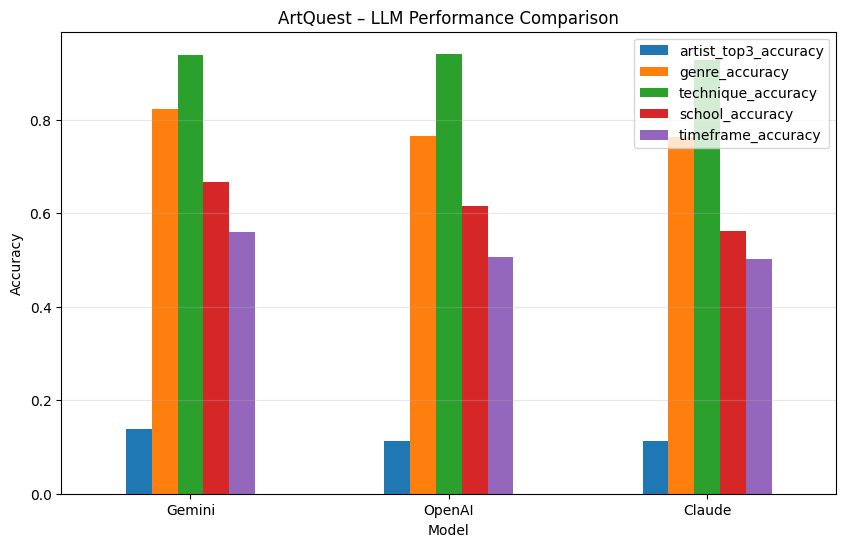

In [ ]:
import matplotlib.pyplot as plt

plot_df = comparison_artquest.set_index("model")[[
    "artist_top3_accuracy",
    "genre_accuracy",
    "technique_accuracy",
    "school_accuracy",
    "timeframe_accuracy"
]]

plot_df.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("ArtQuest – LLM Performance Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
artquest_gemini_long = df_gem_art_valid.copy()

artquest_gemini_long["dataset"] = "ArtQuest"
artquest_gemini_long["model"] = "Gemini"

In [ ]:
artquest_openai_long = df_open_art_valid.copy()

artquest_openai_long["dataset"] = "ArtQuest"
artquest_openai_long["model"] = "OpenAI"

In [ ]:
artquest_claude_long = df_cla_art_valid.copy()

artquest_claude_long["dataset"] = "ArtQuest"
artquest_claude_long["model"] = "Claude"

In [ ]:
artquest_master_long = pd.concat([
    artquest_gemini_long,
    artquest_openai_long,
    artquest_claude_long
], ignore_index=True)

print(artquest_master_long.shape)
display(artquest_master_long.head())

(11118, 32)


,image,true_artist,true_school,true_technique,true_timeframe,true_genre,technique_macro,image_path,ok,error,...,wolfflin_plane_vs_recession,wolfflin_closed_vs_open_form,wolfflin_multiplicity_vs_unity,wolfflin_absolute_vs_relative_clarity,artist_top3_correct,genre_correct,technique_correct,school_correct,timeframe_correct,dataset
0,19337-14july.jpg,Childe HASSAM,american,oil,1851-1900,historical,oil,/content/semart_subset/SemArt_subset/19337-14j...,True,NaN,...,5.0,5.0,5.0,5.0,False,False,True,False,True,ArtQuest
1,43355-ambrose.jpg,Alvise VIVARINI,italian,oil,1451-1500,religious,oil,/content/semart_subset/SemArt_subset/43355-amb...,True,NaN,...,4.0,2.0,4.0,1.0,False,True,True,True,True,ArtQuest
2,12175-cro_f_2.jpg,DUCCIO di Buoninsegna,italian,tempera,1301-1350,religious,tempera,/content/semart_subset/SemArt_subset/12175-cro...,True,NaN,...,3.0,2.0,3.0,2.0,True,True,True,True,True,ArtQuest
3,15171-coronat.jpg,GENTILE DA FABRIANO,italian,tempera,1351-1400,religious,tempera,/content/semart_subset/SemArt_subset/15171-cor...,True,NaN,...,2.0,2.0,2.0,1.0,True,True,True,True,False,ArtQuest
4,20692-bowyer.jpg,Cornelius the Elder JONSON VAN CEULEN,flemish,oil,1601-1650,portrait,oil,/content/semart_subset/SemArt_subset/20692-bow...,True,NaN,...,4.0,4.0,4.0,4.0,False,True,True,False,False,ArtQuest


In [ ]:
wikiart_master_long = pd.read_csv("/content/wikiart_master_predictions_long.csv")

print(wikiart_master_long.shape)

(20576, 24)


In [ ]:
all_datasets_master = pd.concat([
    wikiart_master_long,
    artquest_master_long
], ignore_index=True)

print(all_datasets_master.shape)
display(all_datasets_master.head())

(31694, 49)


,dataset,model,image,img_url,true_artist,true_macro_style,true_genre,pred_artist_1,pred_artist_2,pred_artist_3,...,historical_period,short_description,wolfflin_linear_vs_painterly,wolfflin_plane_vs_recession,wolfflin_closed_vs_open_form,wolfflin_multiplicity_vs_unity,wolfflin_absolute_vs_relative_clarity,technique_correct,school_correct,timeframe_correct
0,WikiArt,Gemini,102839-frank-w-benson-river-scene-1921.jpg,https://uploads4.wikiart.org/00191/images/fran...,Frank W. Benson,Impressionism,landscape,J. Alden Weir,John Twachtman,Childe Hassam,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,WikiArt,Gemini,248823-badende-nach-tizian-1.jpg,https://uploads5.wikiart.org/00138/images/manu...,Manuela Sambo,Expressionism,portrait,Arpana Caur,Kiki Smith,Frida Kahlo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,WikiArt,Gemini,161158-rock-painting-motif.jpg,https://uploads4.wikiart.org/images/walter-bat...,Walter Battiss,Naïve / Outsider,other,Hans Hartung,Pierre Soulages,Wols,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,WikiArt,Gemini,39240-s-l1600.jpg,https://uploads3.wikiart.org/00332/images/alex...,Alexander Clarot,Romanticism,portrait,Jean-Baptiste Isabey,Daniel Saint,Sir William Ross,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,WikiArt,Gemini,24258-francis-godolphin-2nd-earl-of-godolphin-...,https://uploads8.wikiart.org/00308/images/jean...,Jean-Baptiste van Loo,Baroque,portrait,Sir Godfrey Kneller,Jonathan Richardson the Elder,Joseph Highmore,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
all_datasets_master.to_csv(
    "LLM_art_history_master_dataset.csv",
    index=False
)

print("Dataset finale salvato.")

Dataset finale salvato.
